# Localization Analysis — Unitree go2

**Course:** Ciência de Dados — FEI Mestrado  
**Description:** Analysis of RTABMAP localization quality using one or two cameras in a go2 robot.

---

### Data Sources
| File | Description |
|------|-------------|
| `localization_log.csv` | Per-update metrics from `/rtabmap/info` and `/localization_pose` (inliers, covariance, pose, etc.) |
| `plan_log.csv` | Planned path poses from `/plan` topic, grouped by `plan_id` |

### Sections
1. **Data Loading and Data Processing** — read CSV logs from a given run folder and process all data 
2. **Path Visualization** — planned path vs actual robot trajectory  
3. **Localization Quality** — inliers, hypothesis ratio, covariance over time


### 1. **Data Loading and Data Processing**

In [15]:
import math
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from scipy.stats.mstats import winsorize
from plotly.subplots import make_subplots

DEBUG = True  # Set to True to print intermediate values


logs_dir = Path("localization_analysis/data/logs")

loc_paths = sorted(logs_dir.glob("logger_csv_*/localization_log.csv"), key=lambda p: int(p.parent.name.split('_')[-1]))
dfs_loc    = [pd.read_csv(loc_path) for loc_path in loc_paths] 

plan_paths = sorted(logs_dir.glob("logger_csv_*/plan_log.csv"), key=lambda p: int(p.parent.name.split('_')[-1]))
dfs_plan    = [pd.read_csv(plan_path) for plan_path in plan_paths] 

In [16]:
print(f' Localization Dataframes: {len(dfs_loc)}\n Plan Dataframes {len(dfs_plan)}') # Number of DF

 Localization Dataframes: 60
 Plan Dataframes 60


In [17]:
# Take the first path that NAV2 stack calculated (the plan_id = 1)
# Exception: run 5 uses plan_id = 13 (plan_id=1-12 starts at an outlier position — undocking)
last_plans = [df[df['plan_id'] == (13 if i == 4 else df['plan_id'].min())] for i, df in enumerate(dfs_plan)]
last_plans[4]

,plan_id,pose_index,x,y
180,13,0,-2.8519,2.1549
181,13,1,-2.8019,2.1049
182,13,2,-2.7519,2.0549
183,13,3,-2.7019,2.0049
184,13,4,-2.6519,1.9549
...,...,...,...,...
328,13,148,1.7117,1.5549
329,13,149,1.7184,1.6049
330,13,150,1.7269,1.6549
331,13,151,1.7370,1.7049


In [18]:
# Drop rows where pose was not yet received (NaN)
actuals = [df.dropna(subset=['pos_x', 'pos_y']) for df in dfs_loc]
actuals

[    timestamp_sec camera_mode  node_id  inliers  matches  inlier_ratio  \
 0    1.775683e+09      double    20082        0        0        0.0000   
 1    1.775683e+09      double    20083        0        0        0.0000   
 2    1.775683e+09      double    20084        0        0        0.0000   
 3    1.775683e+09      double    20085        0        0        0.0000   
 4    1.775683e+09      double    20086        0        0        0.0000   
 5    1.775683e+09      double    20087        0        0        0.0000   
 6    1.775683e+09      double    20088        0        0        0.0000   
 7    1.775683e+09      double    20089        0        0        0.0000   
 8    1.775683e+09      double    20090        0        0        0.0000   
 9    1.775683e+09      double    20091        3       43        0.0079   
 10   1.775683e+09      double    20092        3       29        0.0066   
 11   1.775683e+09      double    20093        3       28        0.0065   
 12   1.775683e+09      d

### 2. **Path Visualization**

In [19]:
n_runs = len(actuals)
cols = 2
rows = math.ceil(n_runs / cols)
titles = [f'Run {i+1}' for i in range(n_runs)]

fig = make_subplots(rows=rows, cols=cols,
                    subplot_titles=titles,
                    shared_yaxes=False)

for i, (actual_df, last_plan) in enumerate(zip(actuals, last_plans)):
    row = i // cols + 1
    col = i % cols + 1

    fig.add_trace(go.Scatter(
        x=last_plan['x'], y=last_plan['y'],
        mode='lines', name='Planned path',
        line=dict(color='royalblue', dash='dash', width=2),
        legendgroup='plan', showlegend=(i == 0)
    ), row=row, col=col)

    fig.add_trace(go.Scatter(
        x=actual_df['pos_x'], y=actual_df['pos_y'],
        mode='lines', name=f'Run {i+1}',
        line=dict(color='tomato', width=2),
        legendgroup=f'run{i+1}'
    ), row=row, col=col)

fig.update_yaxes(scaleanchor='x', scaleratio=1)
fig.update_layout(
    title='Planned vs Actual Path',
    hovermode='closest',
    height=500 * rows,
    width=900
)
fig.show()


#### 2.1 **Normalizing and get the median of all plans and paths**

##### 2.1.1 **Plans**

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.9192 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.71808554 8.76853244 8.8192498  8.8692498  8.9192498 ]
  arc_norm[:5]  : [0.         0.         0.         0.00792787 0.01585575]
  arc_norm[-5:] : [0.97744606 0.98310201 0.98878829 0.99439415 1.        ]
  resampled to  : 500 points


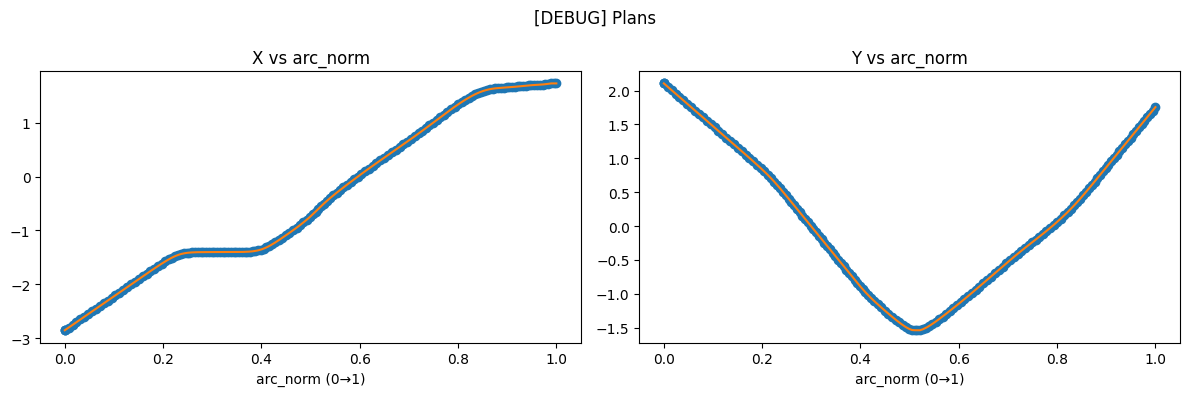

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


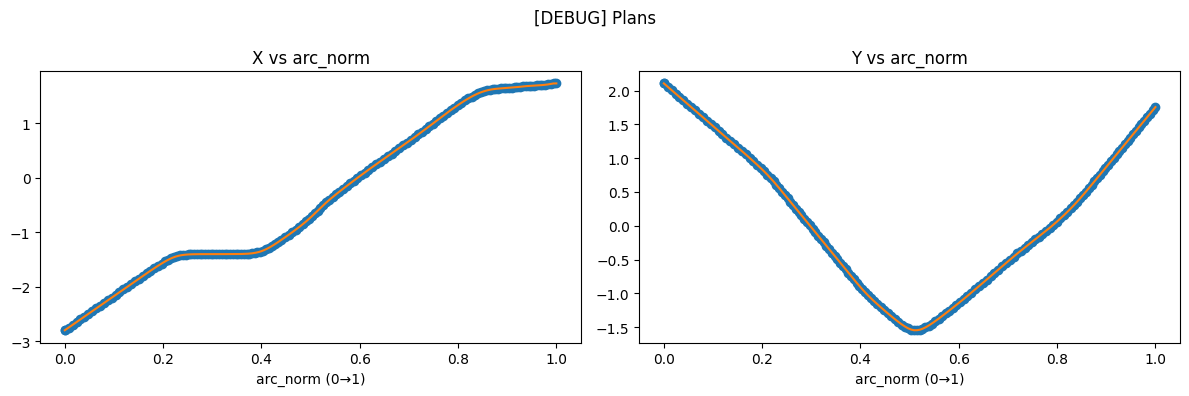

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5513, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9519 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.75075273 8.80119963 8.85191698 8.90191698 8.95191698]
  arc_norm[:5]  : [0.         0.         0.         0.00789894 0.01579789]
  arc_norm[-5:] : [0.97752836 0.98316368 0.98882921 0.9944146  1.        ]
  resampled to  : 500 points


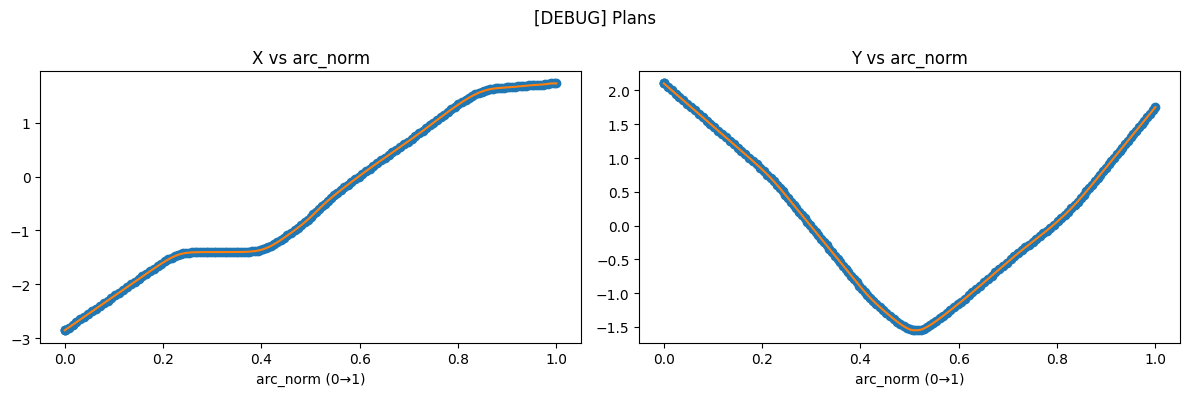

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8985 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.69737486 8.74782176 8.79853912 8.84853912 8.89853912]
  arc_norm[:5]  : [0.         0.         0.         0.00794632 0.01589265]
  arc_norm[-5:] : [0.97739356 0.98306269 0.9887622  0.9943811  1.        ]
  resampled to  : 500 points


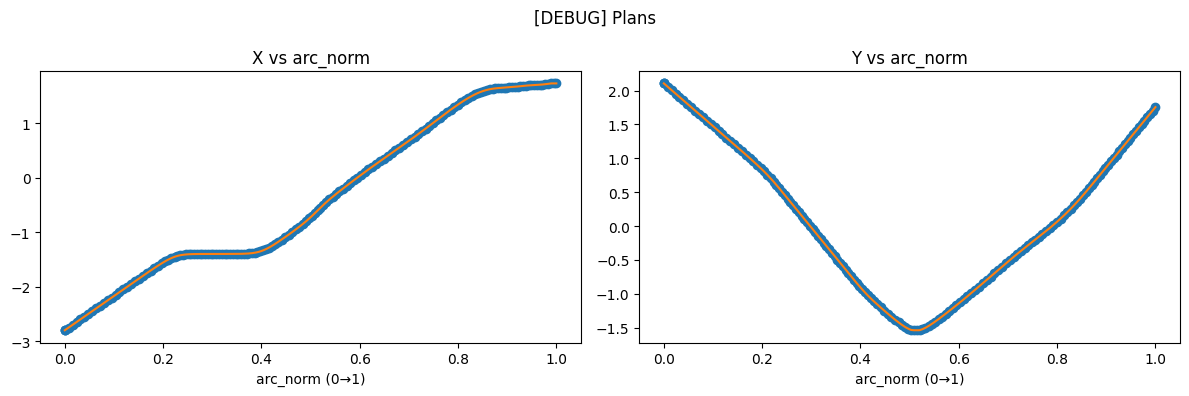

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


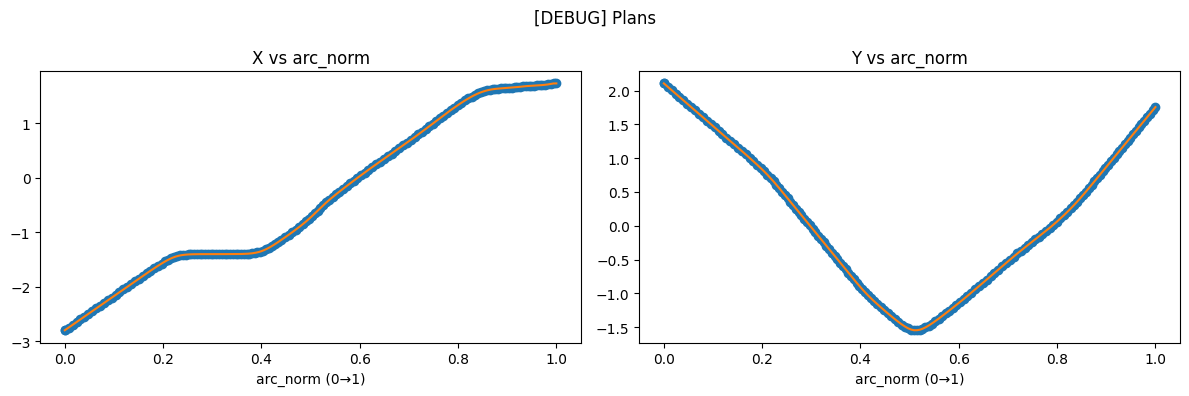

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9214 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.71921051 8.76965741 8.82037476 8.87138466 8.92138466]
  arc_norm[:5]  : [0.         0.         0.00792598 0.01585195 0.02377793]
  arc_norm[-5:] : [0.97733825 0.98299286 0.98867778 0.99439549 1.        ]
  resampled to  : 500 points


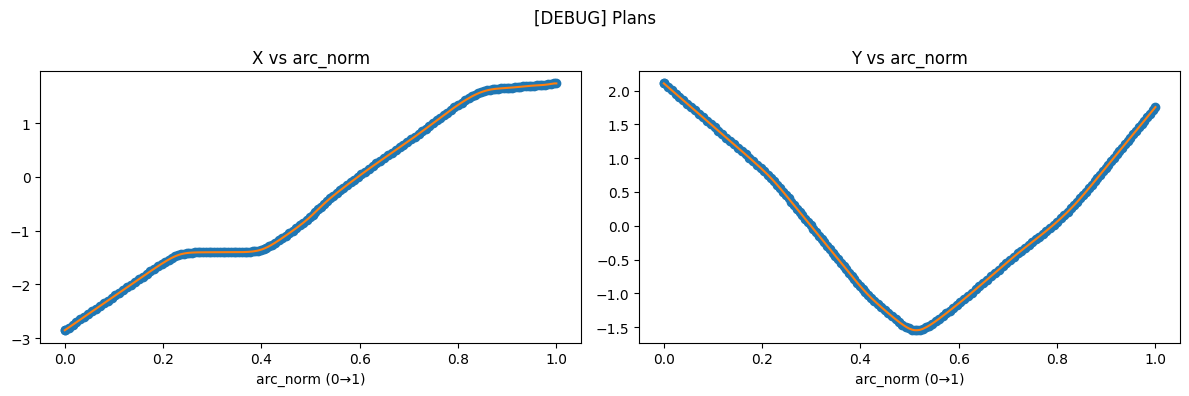

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


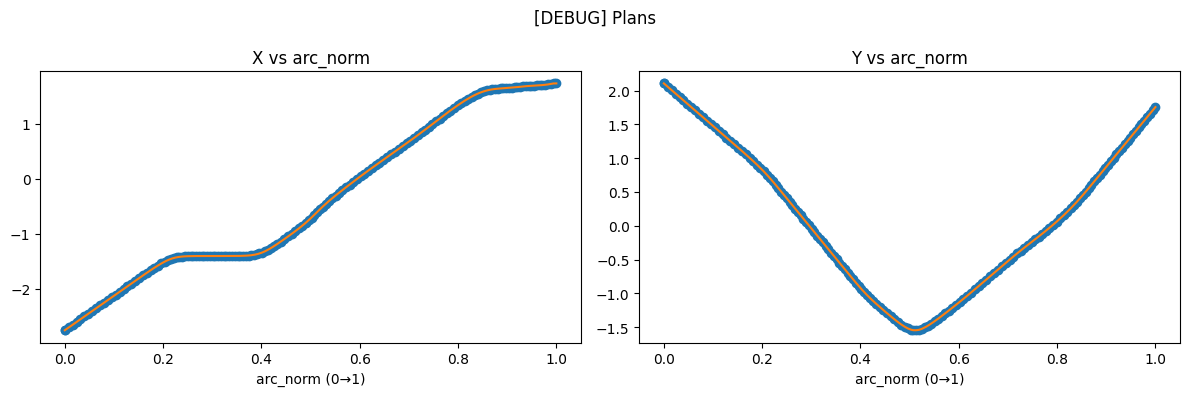

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


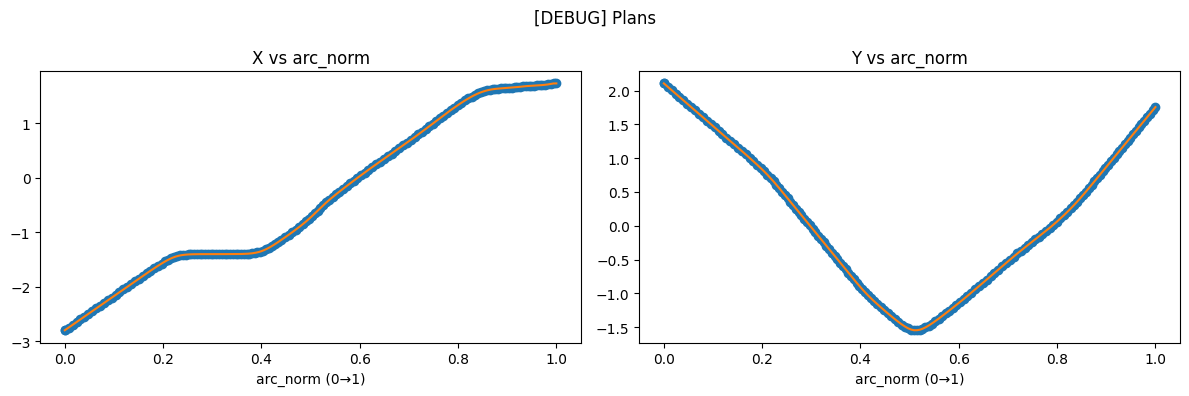

[winsorize_and_resample — plans]
  input rows    : 152
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.0549]
[arc_length_parametrize]
  n_points      : 152
  total length  : 8.8300 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.62778915 8.67823605 8.72895341 8.77996331 8.82996331]
  arc_norm[:5]  : [0.         0.         0.00800804 0.01601608 0.02402411]
  arc_norm[-5:] : [0.97710362 0.98281677 0.98856055 0.99433746 1.        ]
  resampled to  : 500 points


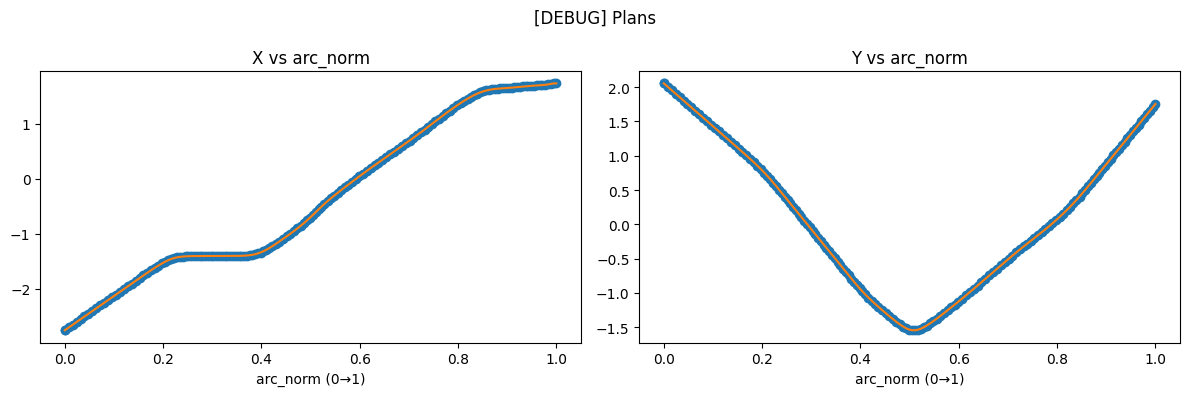

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8985 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.69737486 8.74782176 8.79853912 8.84853912 8.89853912]
  arc_norm[:5]  : [0.         0.         0.         0.00794632 0.01589265]
  arc_norm[-5:] : [0.97739356 0.98306269 0.9887622  0.9943811  1.        ]
  resampled to  : 500 points


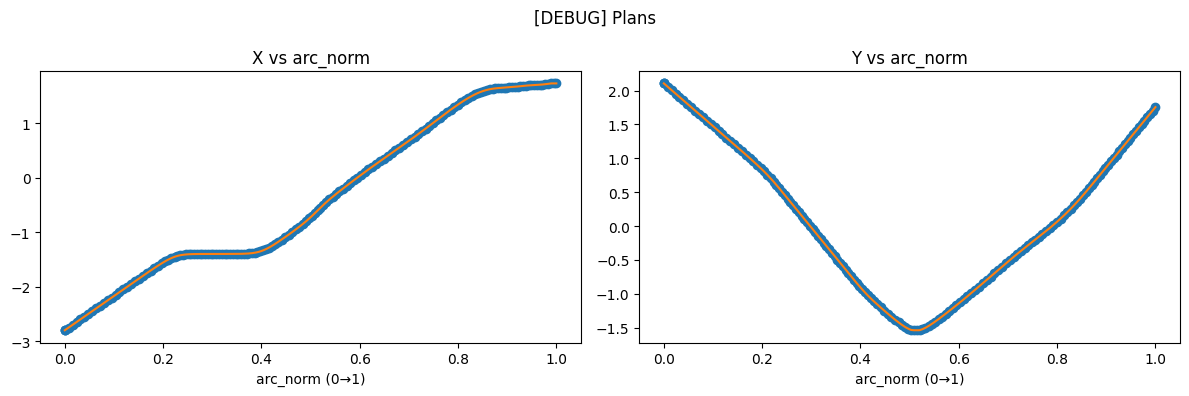

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5513, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9519 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.75075273 8.80119963 8.85191698 8.90191698 8.95191698]
  arc_norm[:5]  : [0.         0.         0.         0.00789894 0.01579789]
  arc_norm[-5:] : [0.97752836 0.98316368 0.98882921 0.9944146  1.        ]
  resampled to  : 500 points


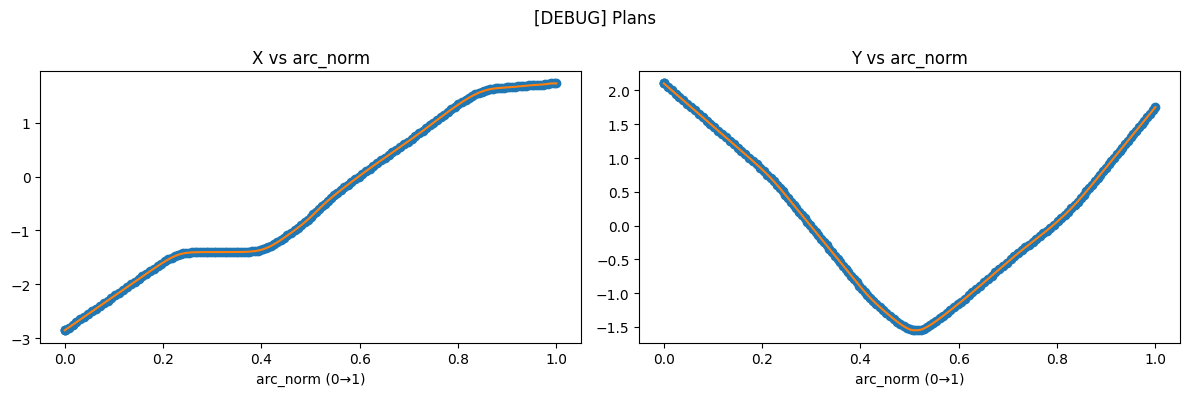

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


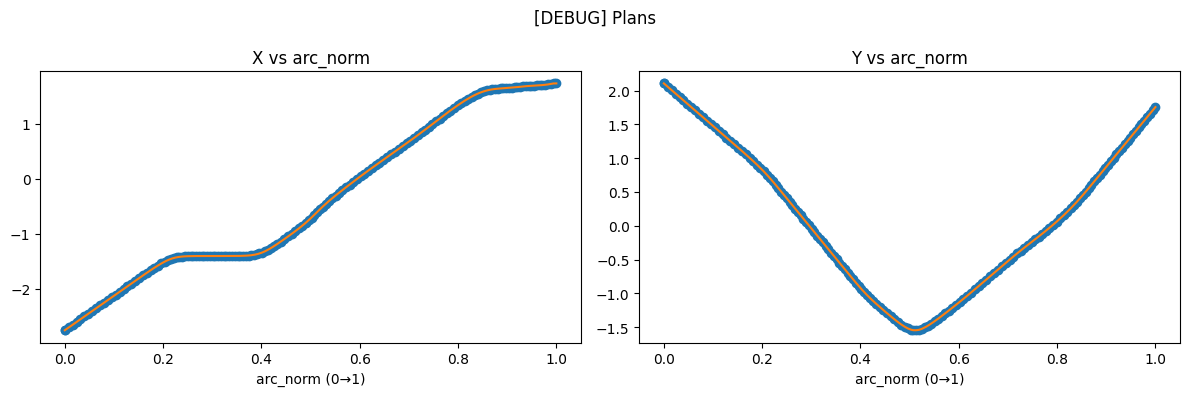

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


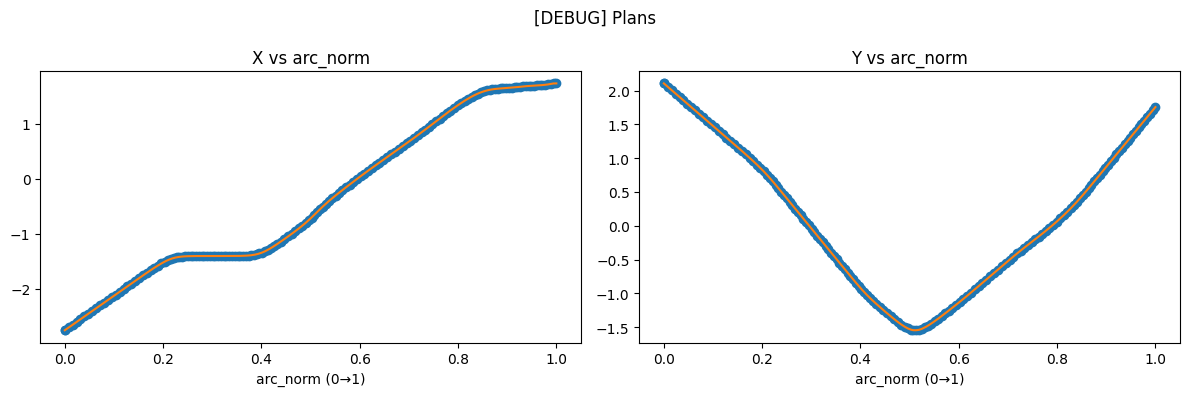

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


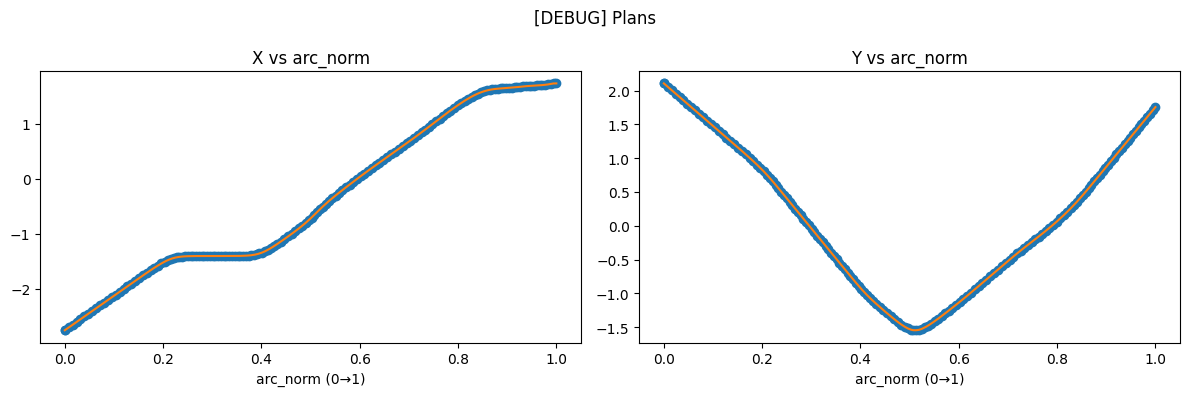

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7019, 1.7269]
  pos_y range   : [-1.5513, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8398 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.63862069 8.6890676  8.73978495 8.78978495 8.83978495]
  arc_norm[:5]  : [0.         0.         0.         0.00799914 0.01599828]
  arc_norm[-5:] : [0.97724331 0.98295011 0.98868751 0.99434375 1.        ]
  resampled to  : 500 points


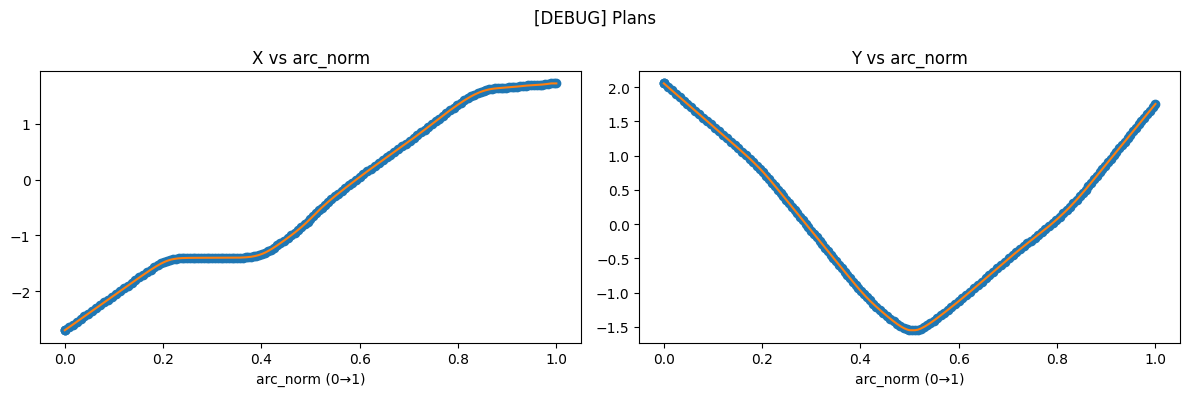

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


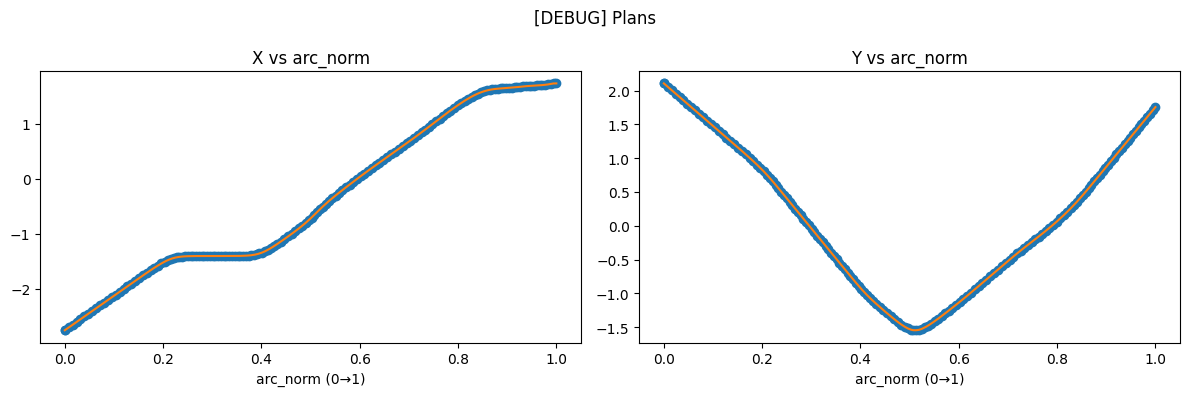

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8778 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.67666418 8.72711109 8.77782844 8.82782844 8.87782844]
  arc_norm[:5]  : [0.         0.         0.         0.00796486 0.01592972]
  arc_norm[-5:] : [0.97734083 0.98302317 0.98873598 0.99436799 1.        ]
  resampled to  : 500 points


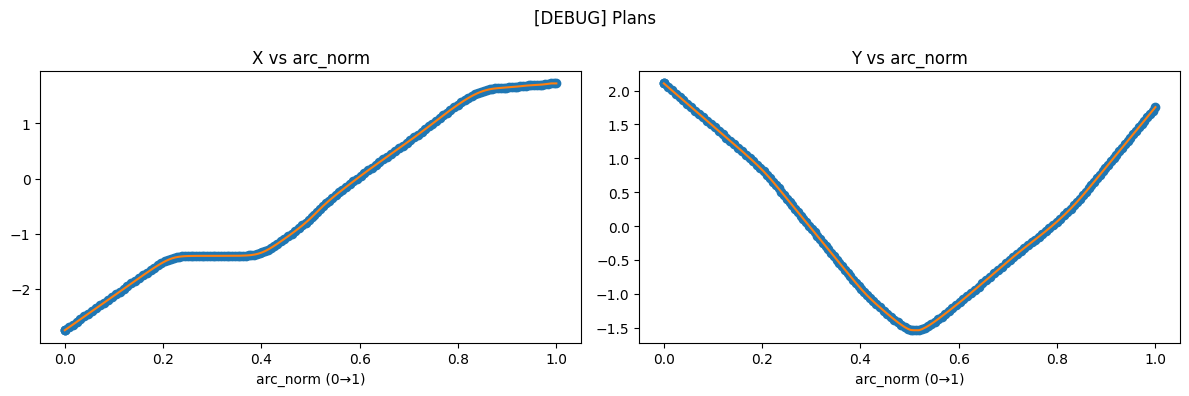

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


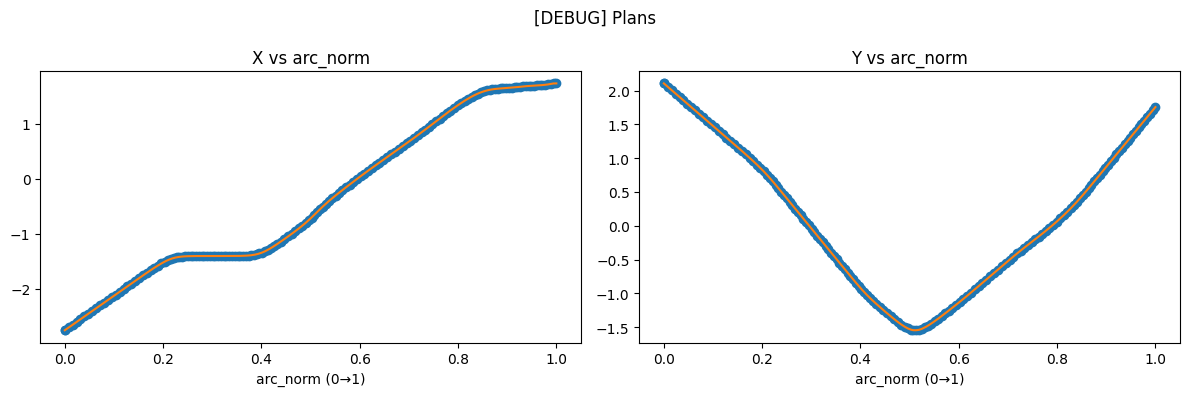

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7019, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8571 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.6559535  8.70640041 8.75711776 8.80711776 8.85711776]
  arc_norm[:5]  : [0.         0.         0.         0.00798349 0.01596697]
  arc_norm[-5:] : [0.97728784 0.98298348 0.98870965 0.99435482 1.        ]
  resampled to  : 500 points


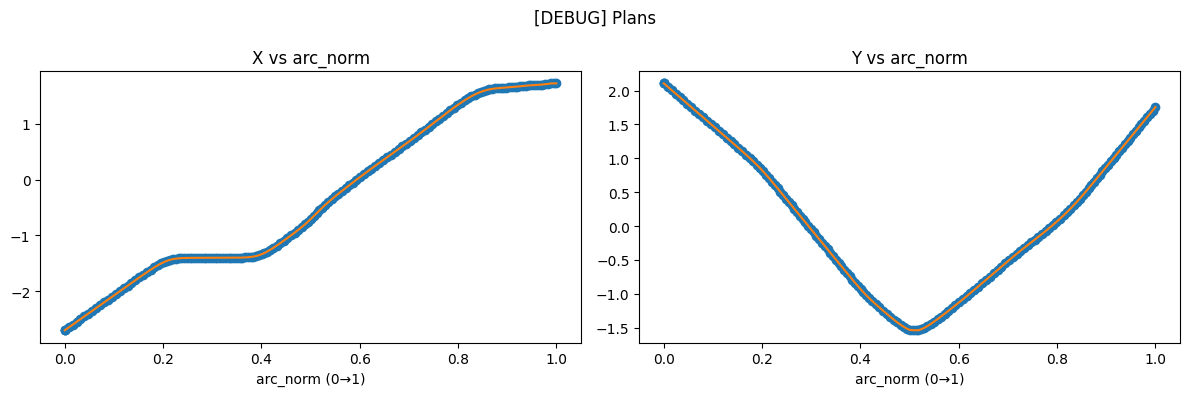

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


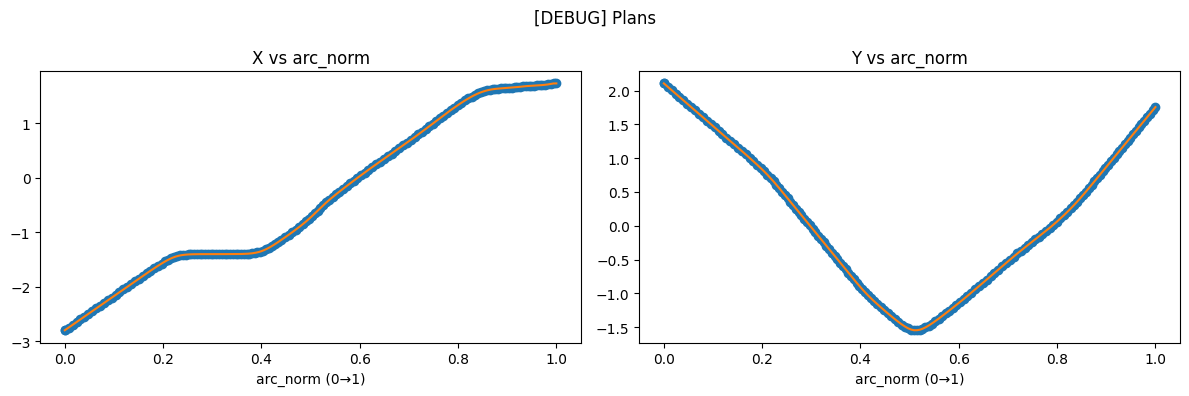

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


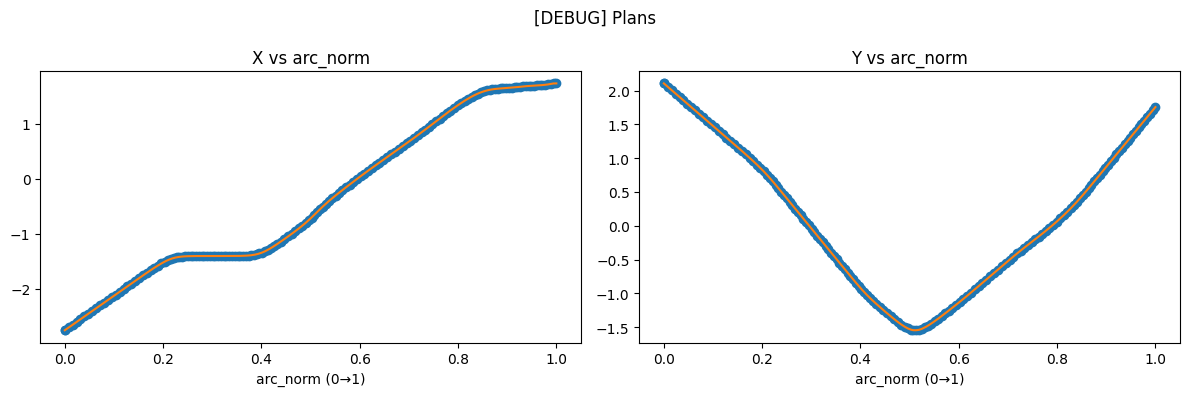

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


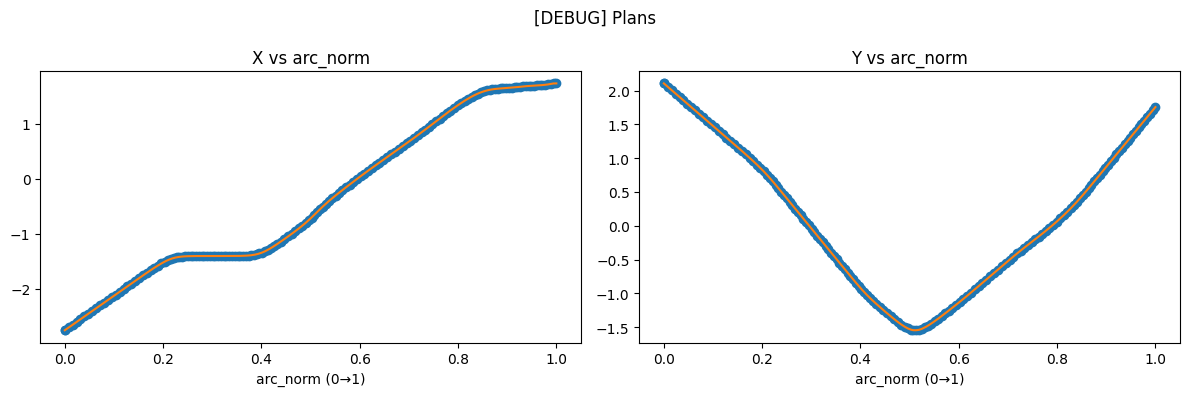

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.5513, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9312 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.73004205 8.78048895 8.83120631 8.88120631 8.93120631]
  arc_norm[:5]  : [0.         0.         0.         0.00791726 0.01583452]
  arc_norm[-5:] : [0.97747625 0.98312464 0.9888033  0.99440165 1.        ]
  resampled to  : 500 points


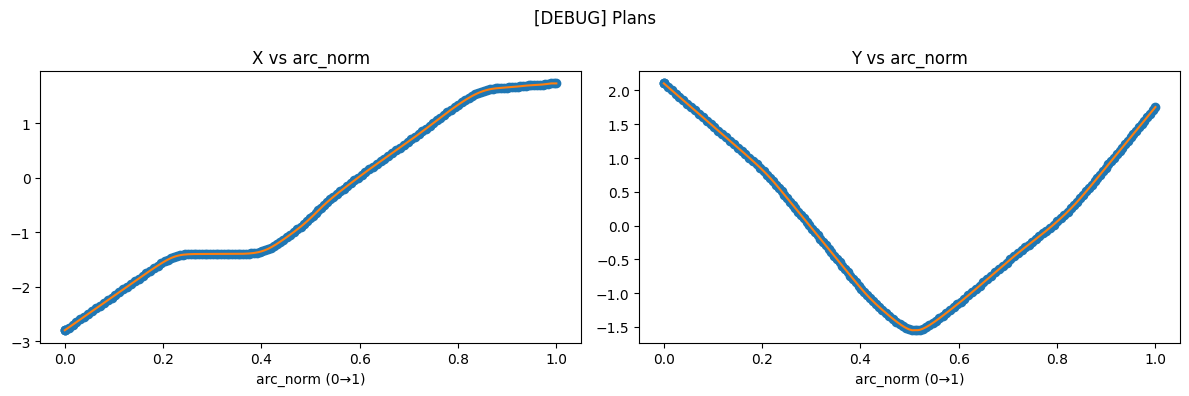

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5513, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8605 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.65933137 8.70977827 8.76049563 8.81049563 8.86049563]
  arc_norm[:5]  : [0.         0.         0.         0.00798044 0.01596089]
  arc_norm[-5:] : [0.9772965  0.98298996 0.98871395 0.99435697 1.        ]
  resampled to  : 500 points


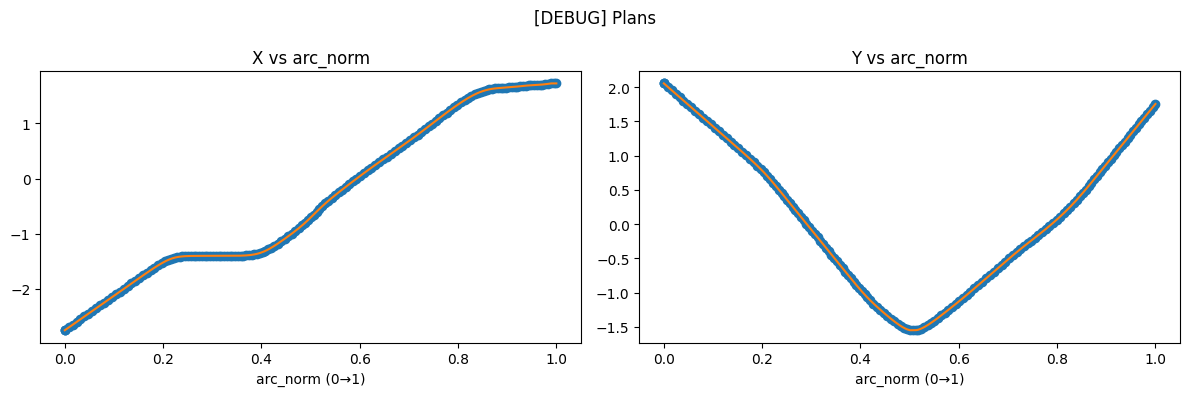

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5513, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8605 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.65933137 8.70977827 8.76049563 8.81049563 8.86049563]
  arc_norm[:5]  : [0.         0.         0.         0.00798044 0.01596089]
  arc_norm[-5:] : [0.9772965  0.98298996 0.98871395 0.99435697 1.        ]
  resampled to  : 500 points


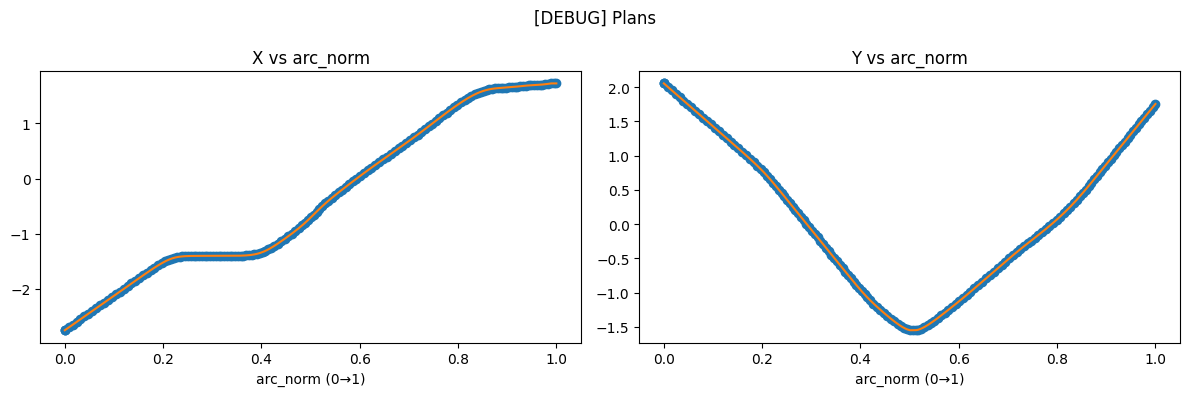

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.9192 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.71808554 8.76853244 8.8192498  8.8692498  8.9192498 ]
  arc_norm[:5]  : [0.         0.         0.         0.00792787 0.01585575]
  arc_norm[-5:] : [0.97744606 0.98310201 0.98878829 0.99439415 1.        ]
  resampled to  : 500 points


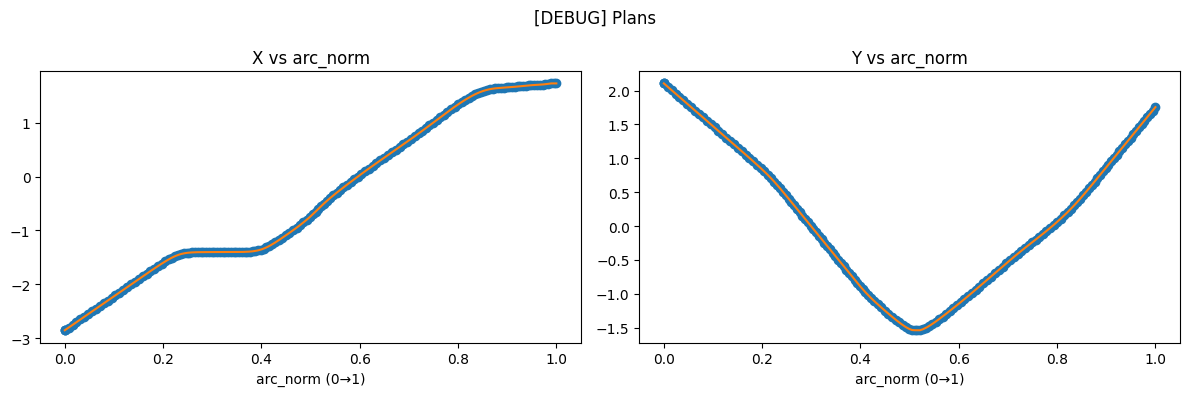

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.9019, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.9400 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.73879622 8.78924312 8.83996047 8.88996047 8.93996047]
  arc_norm[:5]  : [0.         0.         0.         0.00790951 0.01581901]
  arc_norm[-5:] : [0.97749831 0.98314116 0.98881427 0.99440713 1.        ]
  resampled to  : 500 points


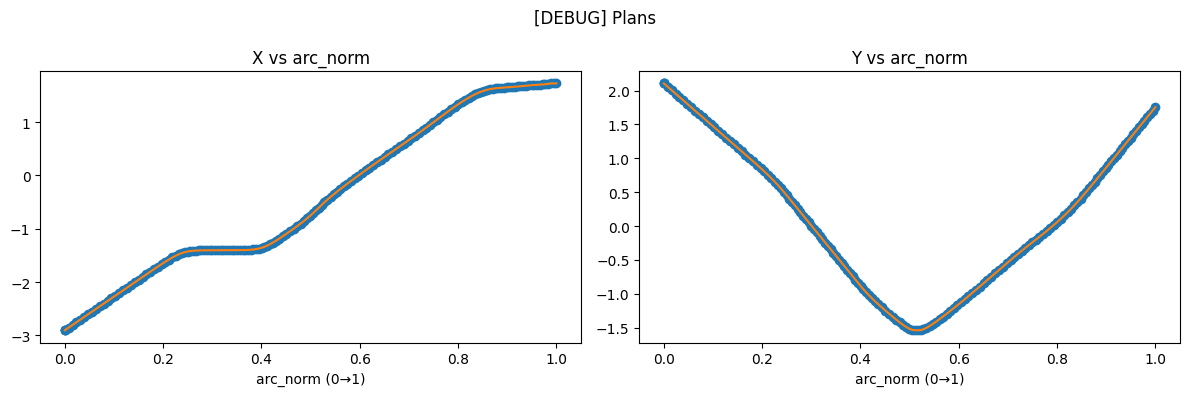

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


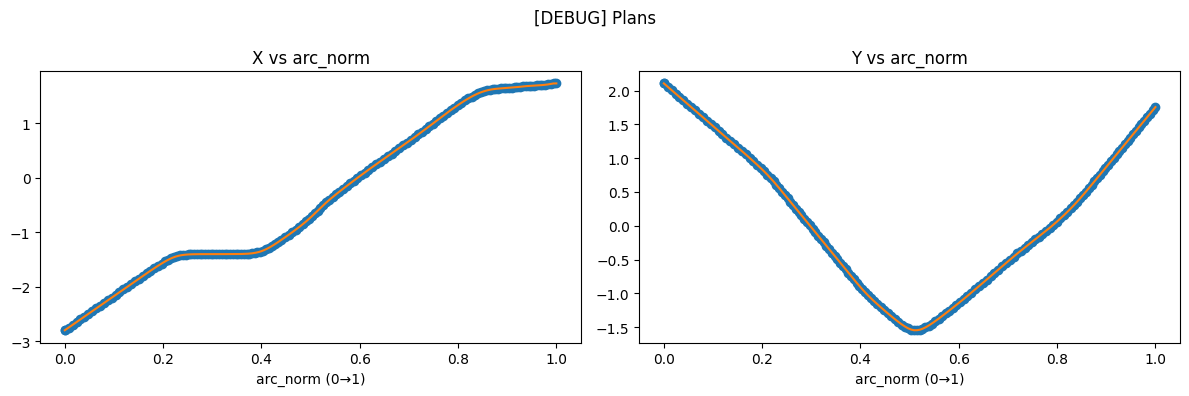

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5513, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.9019 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.70075273 8.75119963 8.80191698 8.85191698 8.90191698]
  arc_norm[:5]  : [0.         0.         0.         0.00794331 0.01588662]
  arc_norm[-5:] : [0.97740214 0.98306911 0.98876646 0.99438323 1.        ]
  resampled to  : 500 points


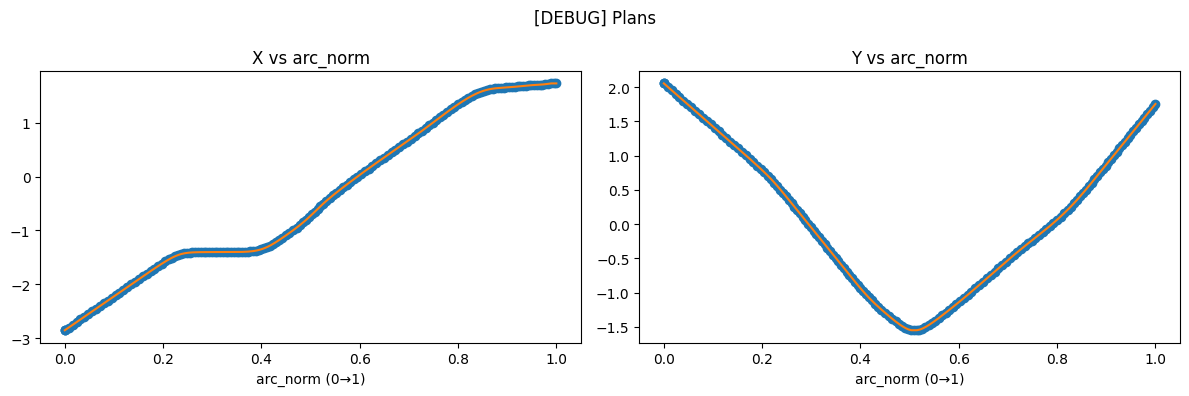

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


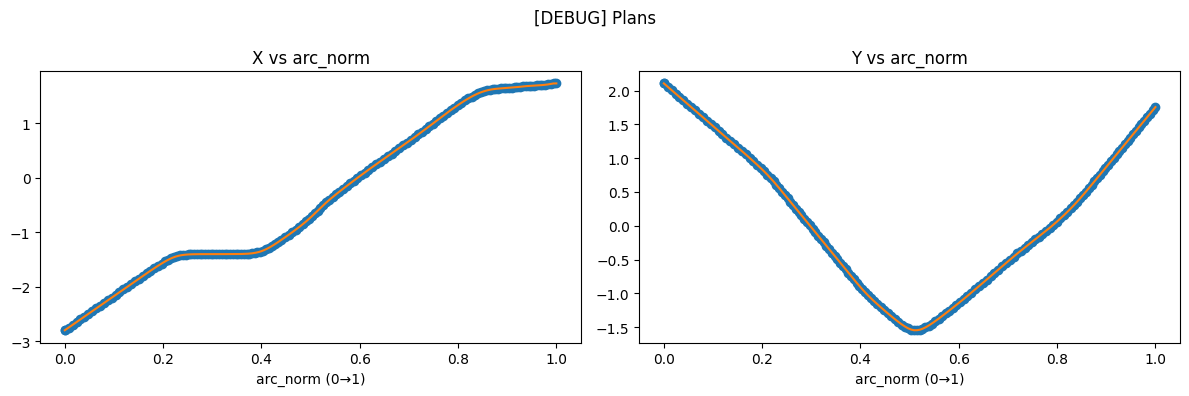

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5382, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8778 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.67666418 8.72711109 8.77782844 8.82782844 8.87782844]
  arc_norm[:5]  : [0.         0.         0.         0.00796486 0.01592972]
  arc_norm[-5:] : [0.97734083 0.98302317 0.98873598 0.99436799 1.        ]
  resampled to  : 500 points


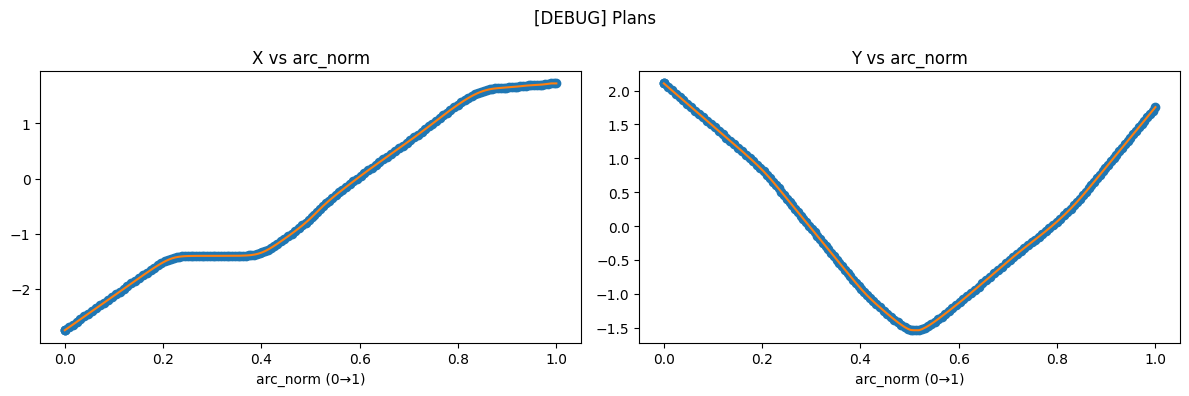

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.9007 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.69849983 8.74894673 8.79966408 8.85067399 8.90067399]
  arc_norm[:5]  : [0.         0.         0.00794442 0.01588884 0.02383326]
  arc_norm[-5:] : [0.97728552 0.98295328 0.98865143 0.99438245 1.        ]
  resampled to  : 500 points


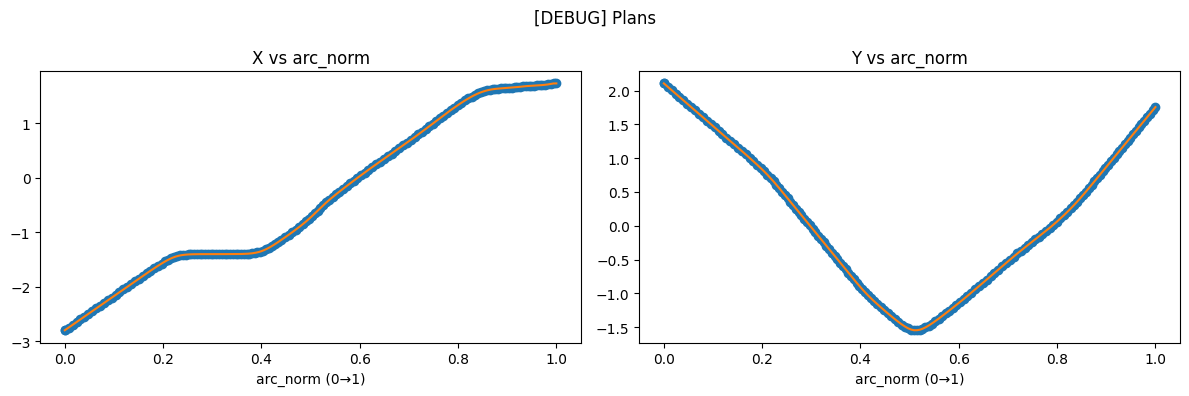

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.5513, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9312 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.73004205 8.78048895 8.83120631 8.88120631 8.93120631]
  arc_norm[:5]  : [0.         0.         0.         0.00791726 0.01583452]
  arc_norm[-5:] : [0.97747625 0.98312464 0.9888033  0.99440165 1.        ]
  resampled to  : 500 points


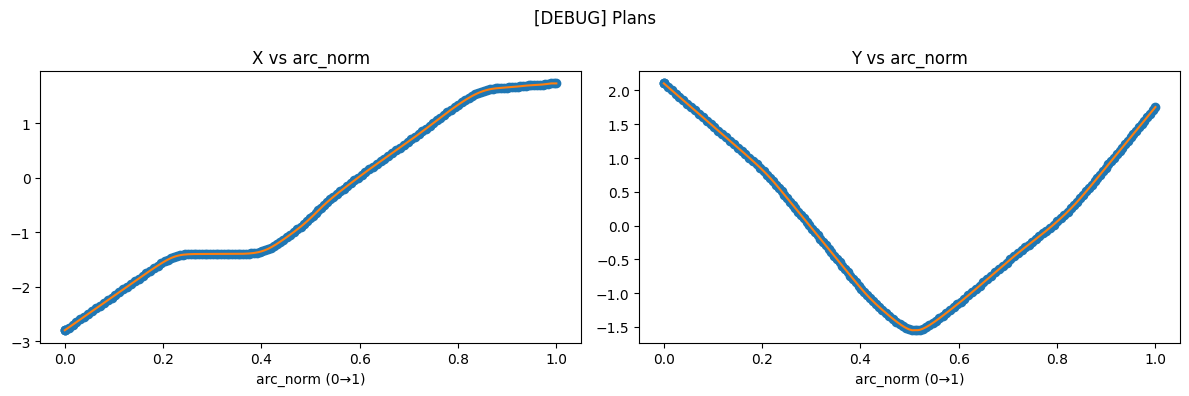

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.67778915 8.72823605 8.77895341 8.82996331 8.87996331]
  arc_norm[:5]  : [0.         0.         0.00796295 0.01592589 0.02388884]
  arc_norm[-5:] : [0.97723255 0.98291353 0.98862496 0.99436935 1.        ]
  resampled to  : 500 points


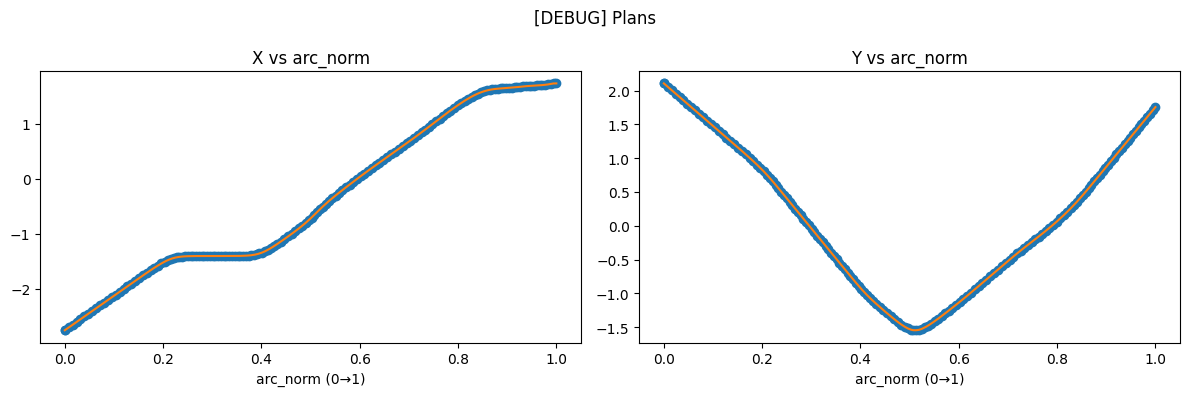

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5513, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8605 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.65933137 8.70977827 8.76049563 8.81049563 8.86049563]
  arc_norm[:5]  : [0.         0.         0.         0.00798044 0.01596089]
  arc_norm[-5:] : [0.9772965  0.98298996 0.98871395 0.99435697 1.        ]
  resampled to  : 500 points


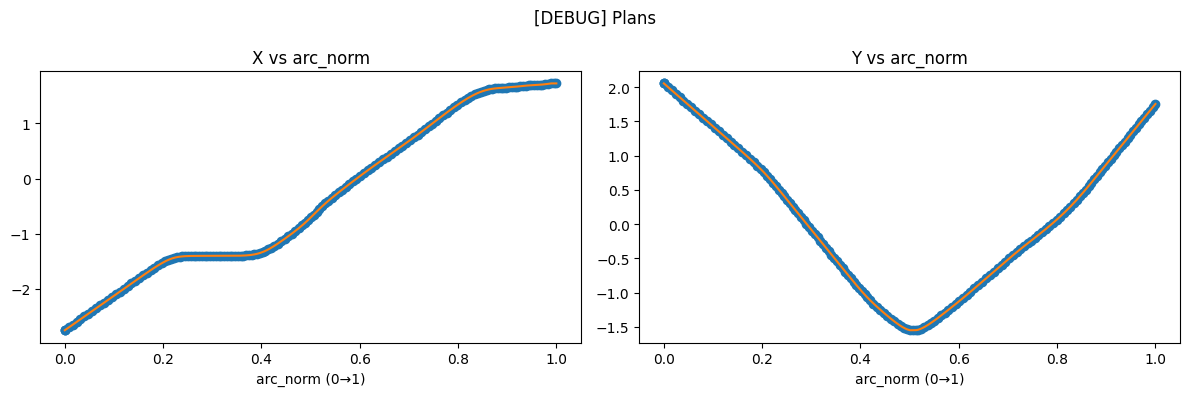

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5382, 2.1549]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9278 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.72666418 8.77711109 8.82782844 8.87782844 8.92782844]
  arc_norm[:5]  : [0.         0.         0.         0.00792026 0.01584051]
  arc_norm[-5:] : [0.97746773 0.98311825 0.98879907 0.99439953 1.        ]
  resampled to  : 500 points


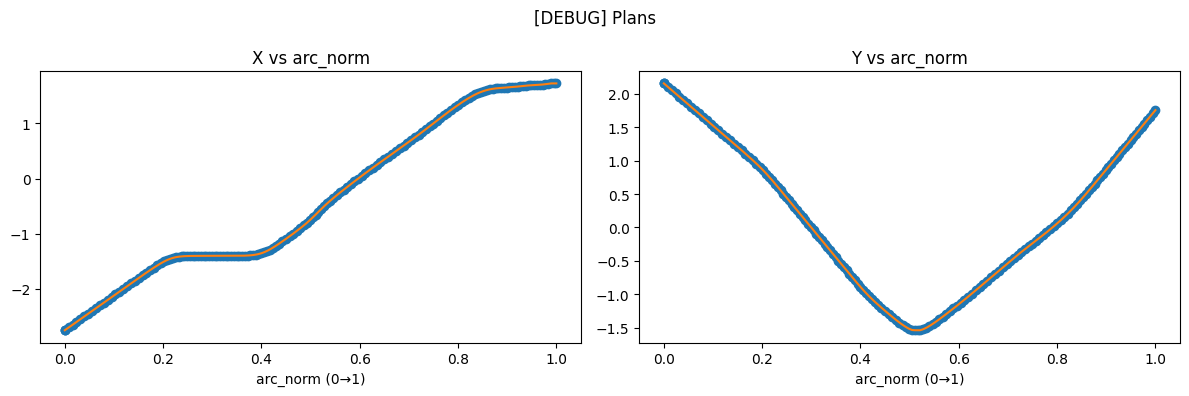

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5513, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.9519 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.75075273 8.80119963 8.85191698 8.90191698 8.95191698]
  arc_norm[:5]  : [0.         0.         0.         0.00789894 0.01579789]
  arc_norm[-5:] : [0.97752836 0.98316368 0.98882921 0.9944146  1.        ]
  resampled to  : 500 points


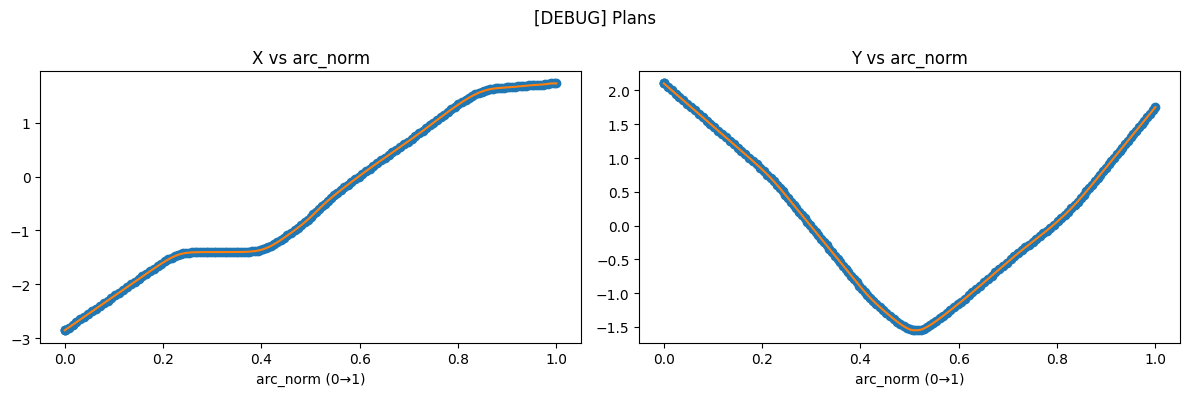

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7380]
  pos_y range   : [-1.5441, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8800 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.6779202  8.72838048 8.7790647  8.8299592  8.8799592 ]
  arc_norm[:5]  : [0.         0.         0.00796295 0.0159259  0.02388885]
  arc_norm[-5:] : [0.97724776 0.98293025 0.98863795 0.99436934 1.        ]
  resampled to  : 500 points


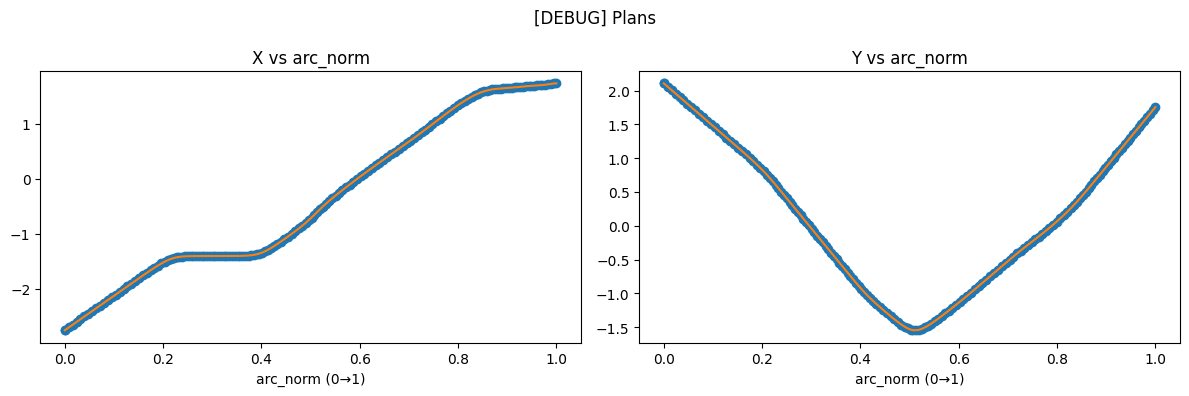

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5080, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8852 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.68399289 8.73443979 8.78515715 8.83515715 8.88515715]
  arc_norm[:5]  : [0.         0.         0.         0.00795829 0.01591658]
  arc_norm[-5:] : [0.97735952 0.98303718 0.98874528 0.99437264 1.        ]
  resampled to  : 500 points


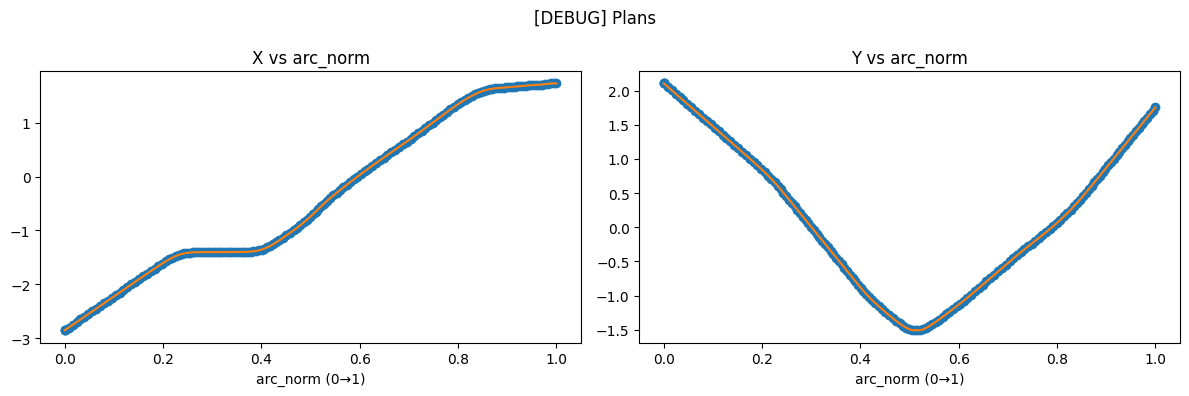

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7019, 1.7269]
  pos_y range   : [-1.5048, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8192 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.618048   8.6684949  8.71921226 8.76921226 8.81921226]
  arc_norm[:5]  : [0.        0.        0.        0.0080178 0.0160356]
  arc_norm[-5:] : [0.97719022 0.98291034 0.98866112 0.99433056 1.        ]
  resampled to  : 500 points


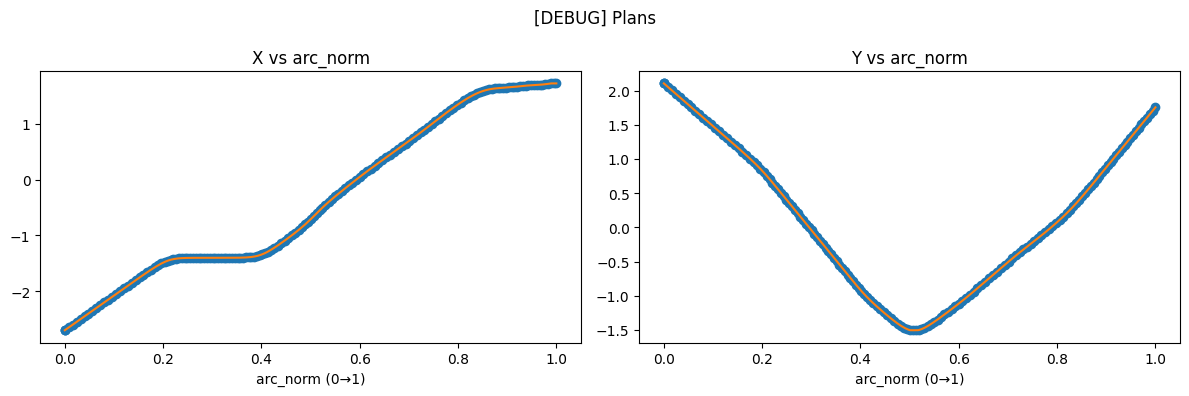

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7019, 1.7269]
  pos_y range   : [-1.5175, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8000 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.59884326 8.64929016 8.70000751 8.75000751 8.80000751]
  arc_norm[:5]  : [0.         0.         0.         0.0080353  0.01607059]
  arc_norm[-5:] : [0.97714044 0.98287304 0.98863637 0.99431819 1.        ]
  resampled to  : 500 points


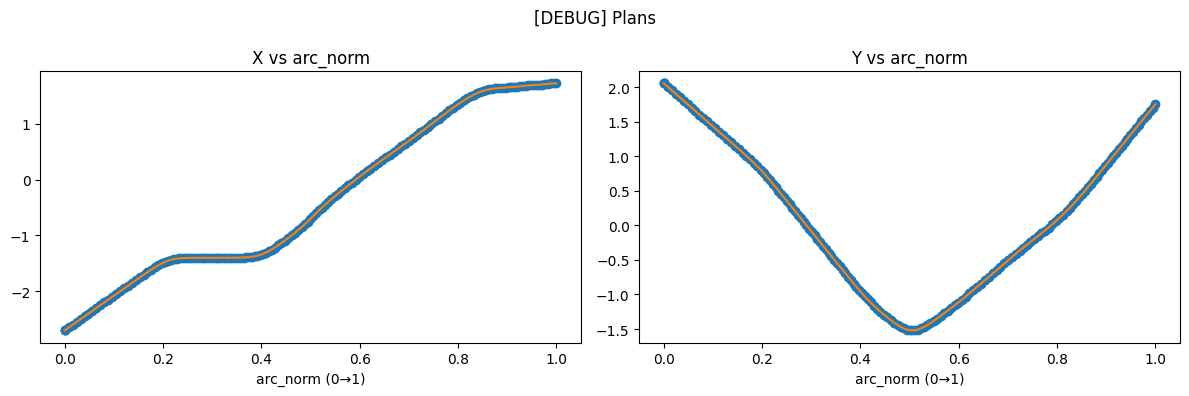

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5048, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8399 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.63875868 8.68920558 8.73992293 8.78992293 8.83992293]
  arc_norm[:5]  : [0.         0.         0.         0.00799902 0.01599803]
  arc_norm[-5:] : [0.97724366 0.98295038 0.98868768 0.99434384 1.        ]
  resampled to  : 500 points


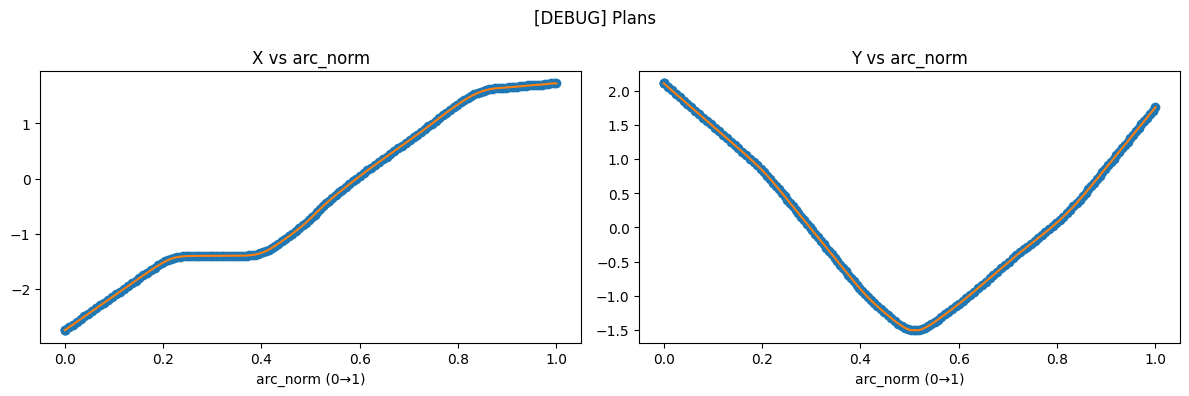

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5199, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.8741 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.67289735 8.72334426 8.77406161 8.82406161 8.87406161]
  arc_norm[:5]  : [0.         0.         0.         0.00796824 0.01593649]
  arc_norm[-5:] : [0.97733121 0.98301597 0.9887312  0.9943656  1.        ]
  resampled to  : 500 points


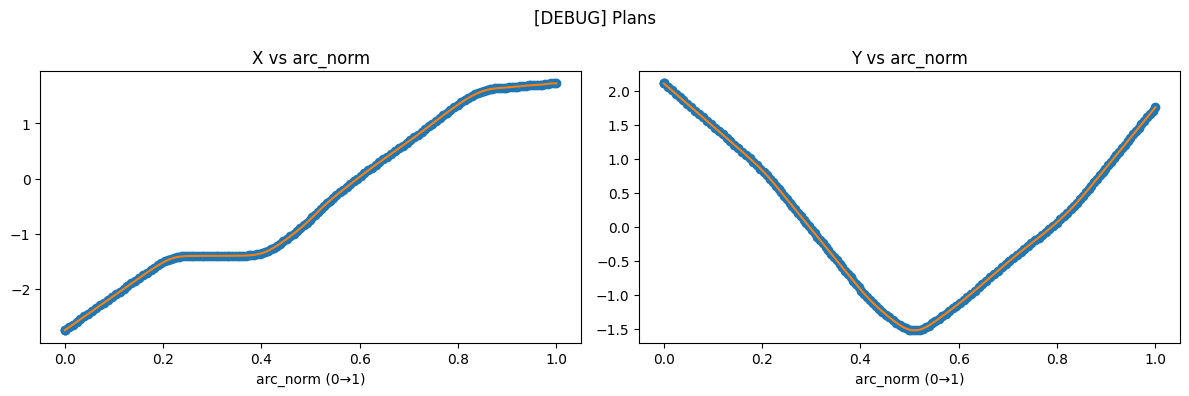

[winsorize_and_resample — plans]
  input rows    : 155
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.5175, 2.1049]
[arc_length_parametrize]
  n_points      : 155
  total length  : 8.8914 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.69026461 8.74071152 8.79142887 8.84142887 8.89142887]
  arc_norm[:5]  : [0.         0.         0.         0.00795268 0.01590536]
  arc_norm[-5:] : [0.97737549 0.98304914 0.98875321 0.99437661 1.        ]
  resampled to  : 500 points


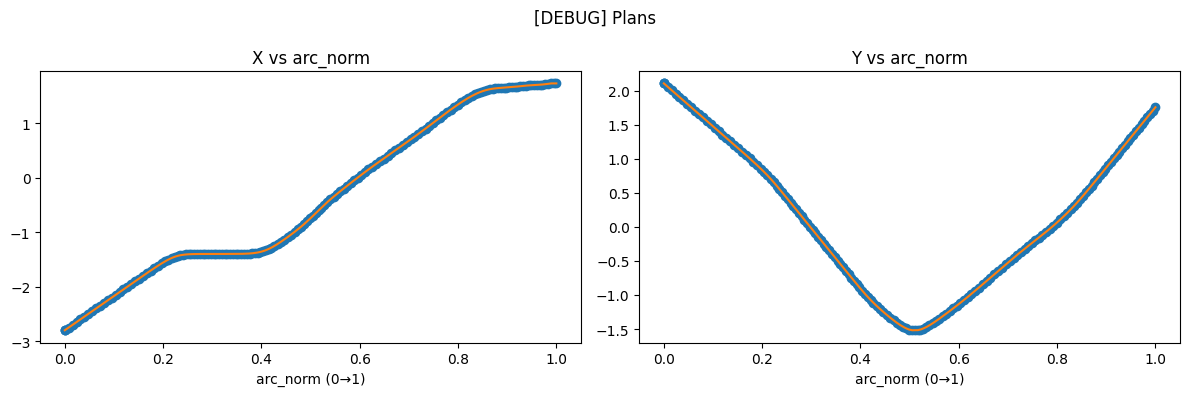

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5110, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8419 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.63969708 8.69014398 8.74086133 8.79187124 8.84187124]
  arc_norm[:5]  : [0.         0.         0.00799725 0.01599451 0.02399176]
  arc_norm[-5:] : [0.97713446 0.98283992 0.98857596 0.99434509 1.        ]
  resampled to  : 500 points


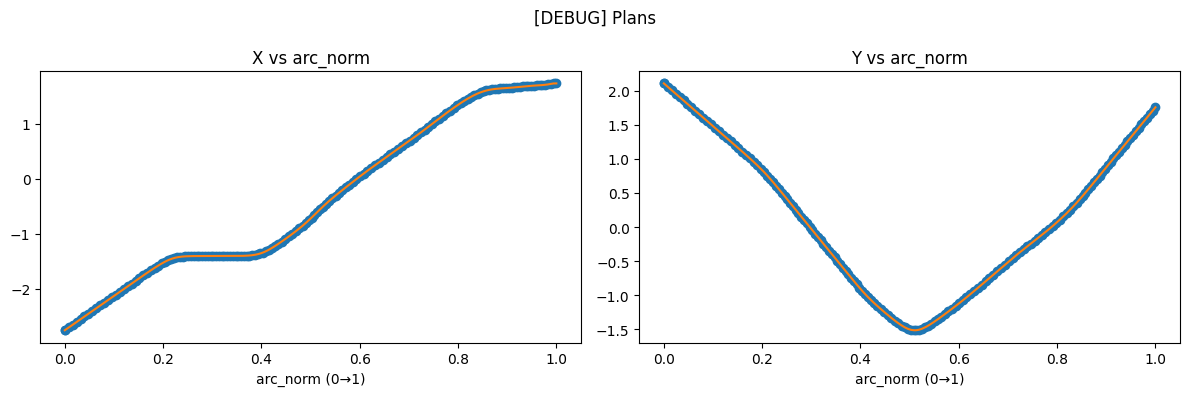

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5110, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8626 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.66040776 8.71085466 8.76157201 8.81258191 8.86258191]
  arc_norm[:5]  : [0.         0.         0.00797856 0.01595713 0.02393569]
  arc_norm[-5:] : [0.97718789 0.98288002 0.98860266 0.9943583  1.        ]
  resampled to  : 500 points


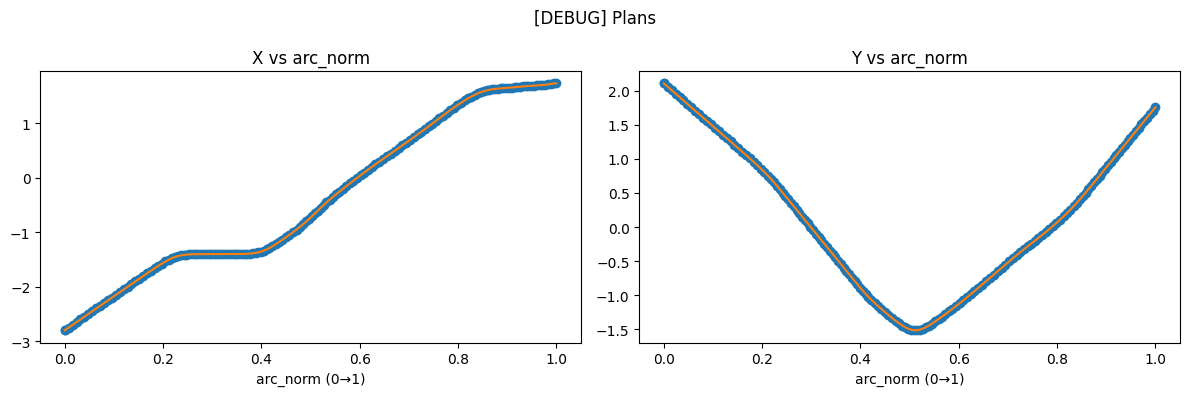

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7019, 1.7370]
  pos_y range   : [-1.5110, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8212 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.6189864  8.6694333  8.72015066 8.77116056 8.82116056]
  arc_norm[:5]  : [0.         0.         0.00801603 0.01603206 0.02404809]
  arc_norm[-5:] : [0.97708078 0.98279963 0.98854914 0.99433181 1.        ]
  resampled to  : 500 points


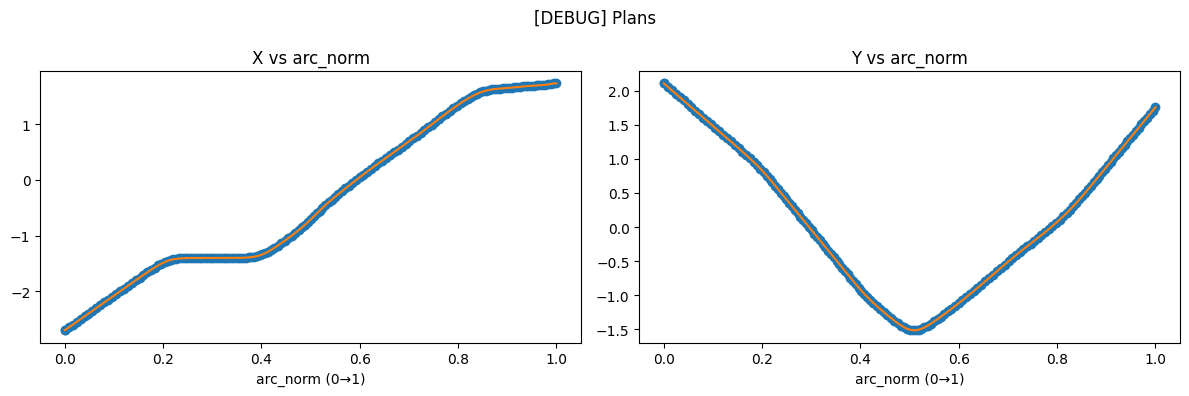

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5145, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8665 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.66427911 8.71472601 8.76544336 8.81645326 8.86645326]
  arc_norm[:5]  : [0.         0.         0.00797508 0.01595016 0.02392524]
  arc_norm[-5:] : [0.97719785 0.98288749 0.98860763 0.99436077 1.        ]
  resampled to  : 500 points


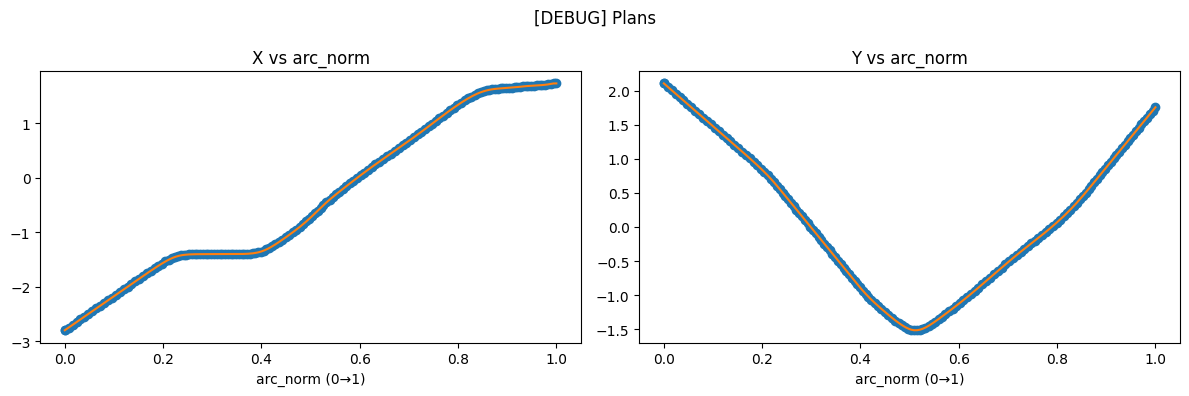

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5110, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8626 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.66040776 8.71085466 8.76157201 8.81258191 8.86258191]
  arc_norm[:5]  : [0.         0.         0.00797856 0.01595713 0.02393569]
  arc_norm[-5:] : [0.97718789 0.98288002 0.98860266 0.9943583  1.        ]
  resampled to  : 500 points


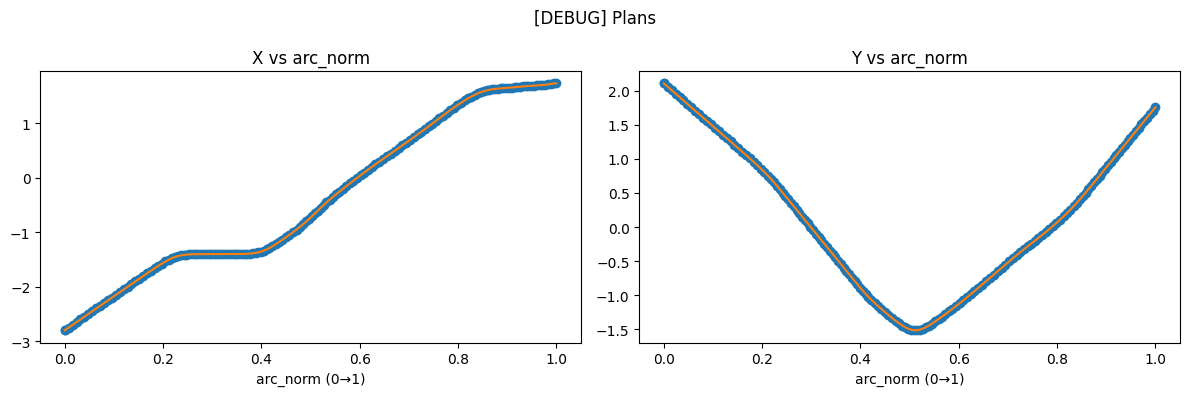

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5093, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8129 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.61177371 8.66222061 8.71293796 8.76293796 8.81293796]
  arc_norm[:5]  : [0.         0.         0.         0.00802351 0.01604702]
  arc_norm[-5:] : [0.97717398 0.98289817 0.98865305 0.99432652 1.        ]
  resampled to  : 500 points


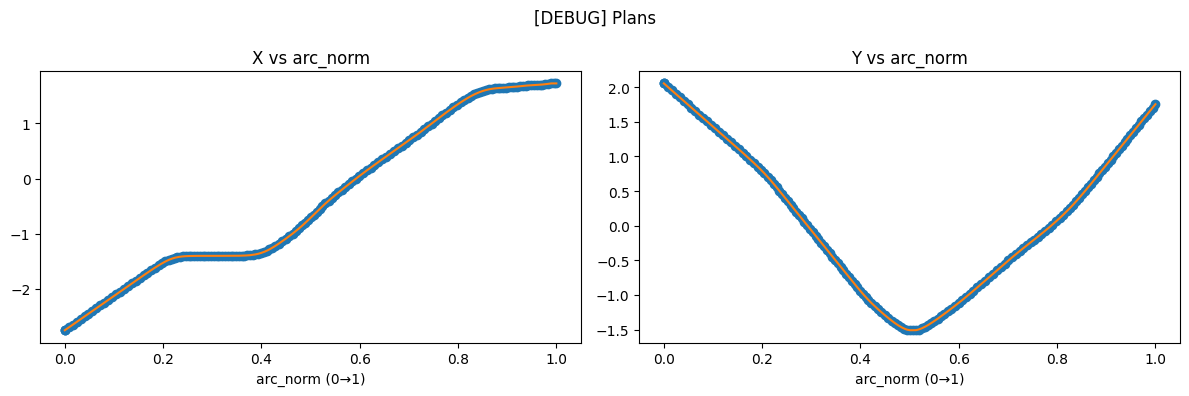

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5029, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8545 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.65233644 8.70278334 8.75350069 8.80451059 8.85451059]
  arc_norm[:5]  : [0.         0.         0.00798584 0.01597167 0.02395751]
  arc_norm[-5:] : [0.9771671  0.98286441 0.98859227 0.99435316 1.        ]
  resampled to  : 500 points


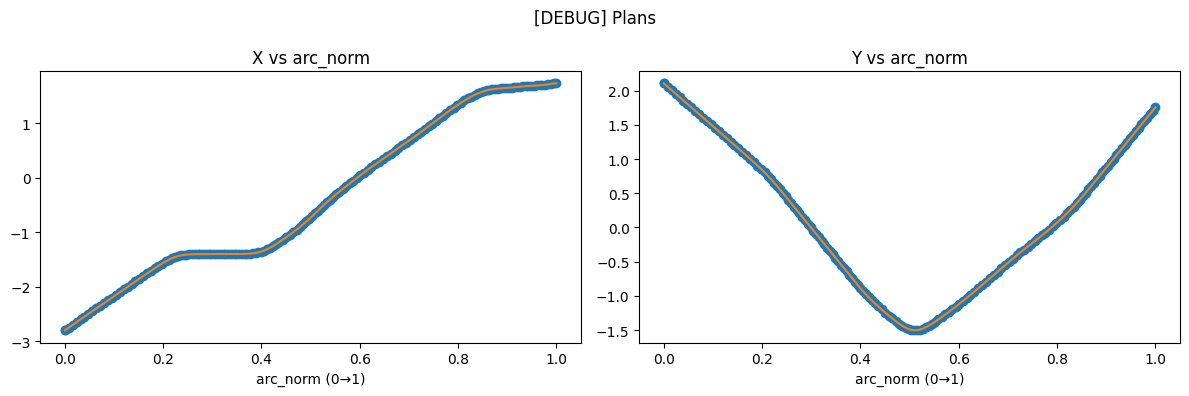

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5029, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8545 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.65233644 8.70278334 8.75350069 8.80451059 8.85451059]
  arc_norm[:5]  : [0.         0.         0.00798584 0.01597167 0.02395751]
  arc_norm[-5:] : [0.9771671  0.98286441 0.98859227 0.99435316 1.        ]
  resampled to  : 500 points


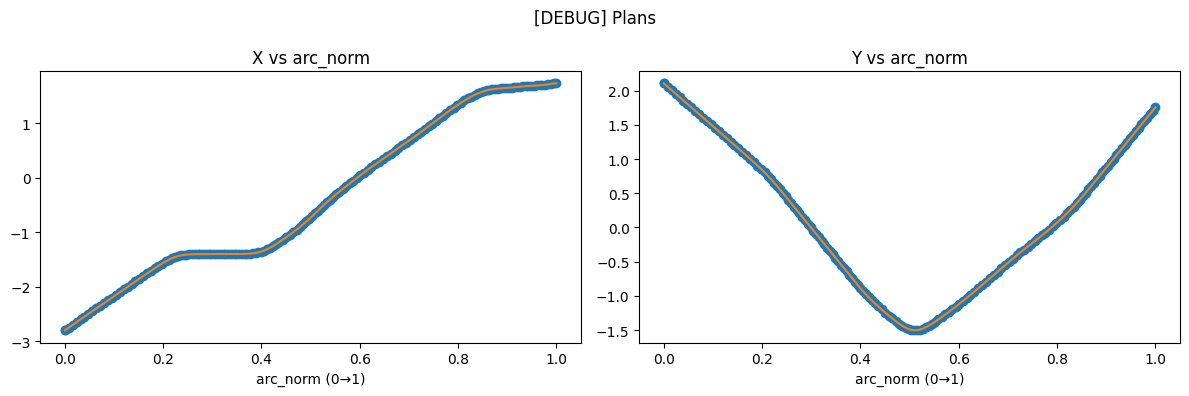

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7269]
  pos_y range   : [-1.5093, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8544 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.65319506 8.70364196 8.75435932 8.80435932 8.85435932]
  arc_norm[:5]  : [0.         0.         0.         0.00798597 0.01597195]
  arc_norm[-5:] : [0.97728077 0.98297818 0.98870613 0.99435306 1.        ]
  resampled to  : 500 points


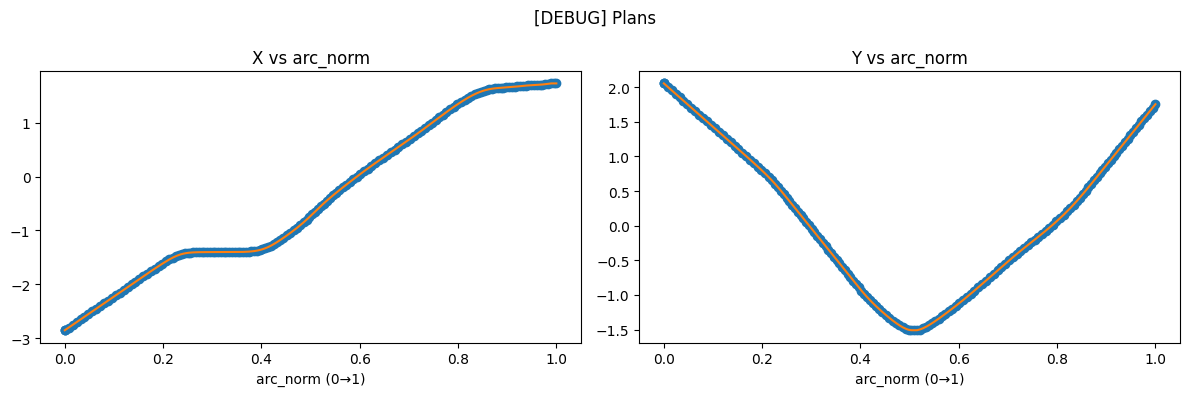

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7380]
  pos_y range   : [-1.5029, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8545 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.65246749 8.70292777 8.75361199 8.80450649 8.85450649]
  arc_norm[:5]  : [0.         0.         0.00798584 0.01597168 0.02395752]
  arc_norm[-5:] : [0.97718235 0.98288118 0.98860529 0.99435316 1.        ]
  resampled to  : 500 points


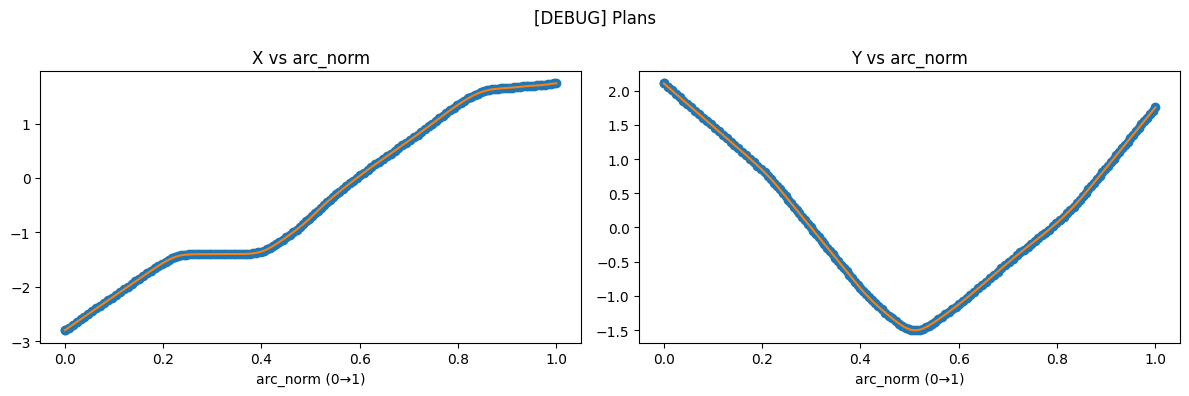

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7285]
  pos_y range   : [-1.4981, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8321 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.63100223 8.68146251 8.73214673 8.78214673 8.83214673]
  arc_norm[:5]  : [0.         0.         0.         0.00800606 0.01601212]
  arc_norm[-5:] : [0.97722587 0.98293912 0.98867772 0.99433886 1.        ]
  resampled to  : 500 points


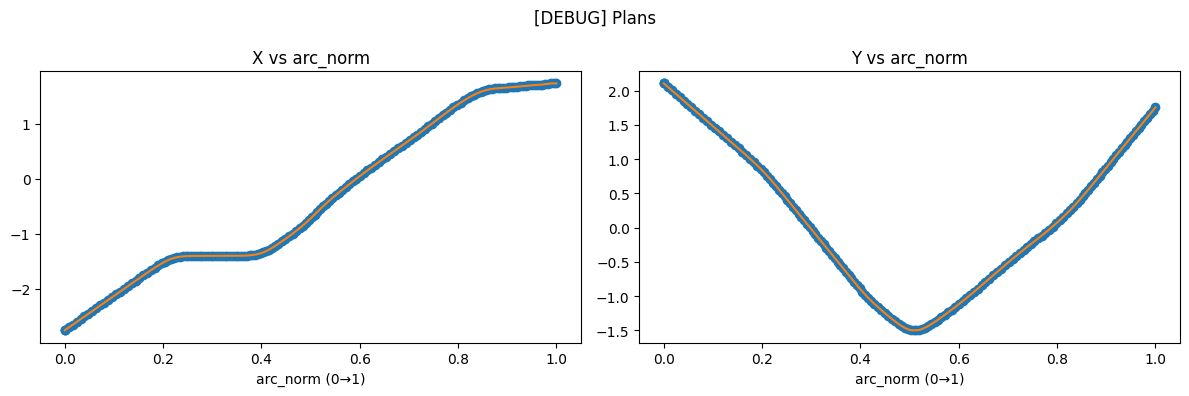

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7370]
  pos_y range   : [-1.5029, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8545 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.65233644 8.70278334 8.75350069 8.80451059 8.85451059]
  arc_norm[:5]  : [0.         0.         0.00798584 0.01597167 0.02395751]
  arc_norm[-5:] : [0.9771671  0.98286441 0.98859227 0.99435316 1.        ]
  resampled to  : 500 points


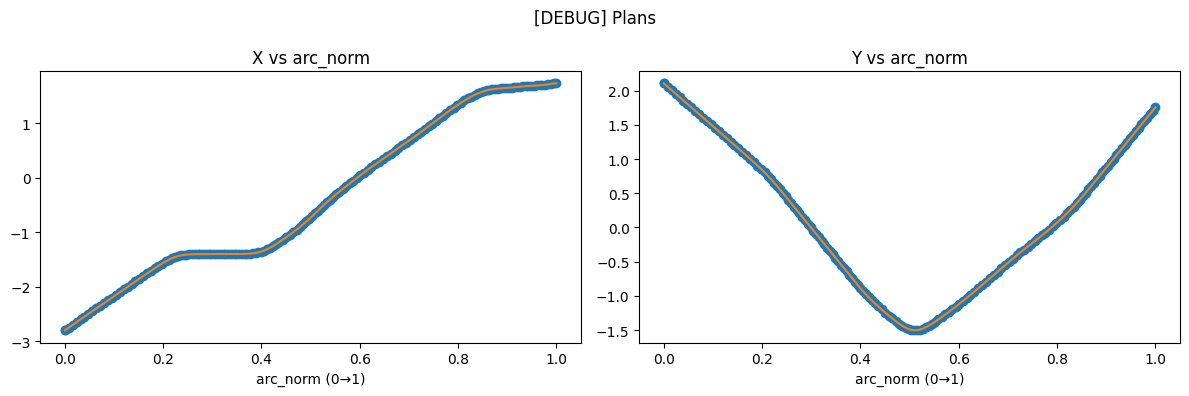

[winsorize_and_resample — plans]
  input rows    : 153
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7370]
  pos_y range   : [-1.5029, 2.1049]
[arc_length_parametrize]
  n_points      : 153
  total length  : 8.8338 m
  arc[:5]  : [0.         0.         0.07071068 0.14142136 0.21213203]
  arc[-5:] : [8.63162576 8.68207266 8.73279001 8.78379992 8.83379992]
  arc_norm[:5]  : [0.         0.         0.00800456 0.01600912 0.02401368]
  arc_norm[-5:] : [0.97711357 0.98282424 0.98856552 0.99433992 1.        ]
  resampled to  : 500 points


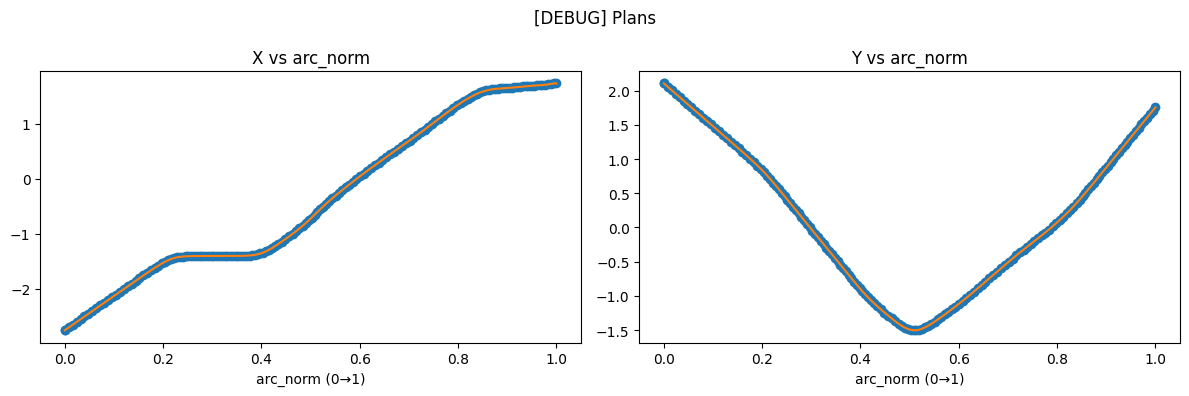

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8519, 1.7285]
  pos_y range   : [-1.4981, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8736 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.67242359 8.72288387 8.77356809 8.82356809 8.87356809]
  arc_norm[:5]  : [0.         0.         0.         0.00796869 0.01593737]
  arc_norm[-5:] : [0.97733217 0.98301876 0.98873058 0.99436529 1.        ]
  resampled to  : 500 points


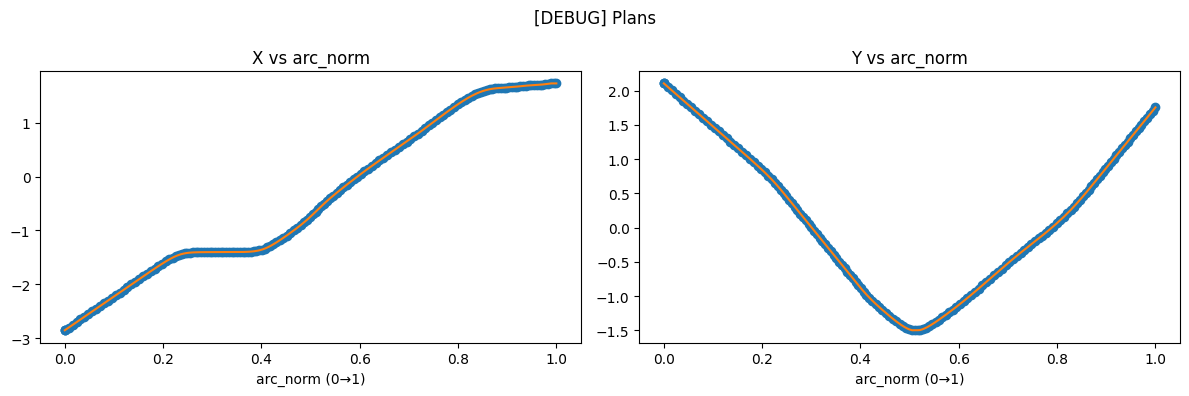

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.8019, 1.7269]
  pos_y range   : [-1.4981, 2.1049]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8527 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.65158186 8.70202876 8.75274612 8.80274612 8.85274612]
  arc_norm[:5]  : [0.         0.         0.         0.00798743 0.01597486]
  arc_norm[-5:] : [0.97727663 0.98297507 0.98870407 0.99435204 1.        ]
  resampled to  : 500 points


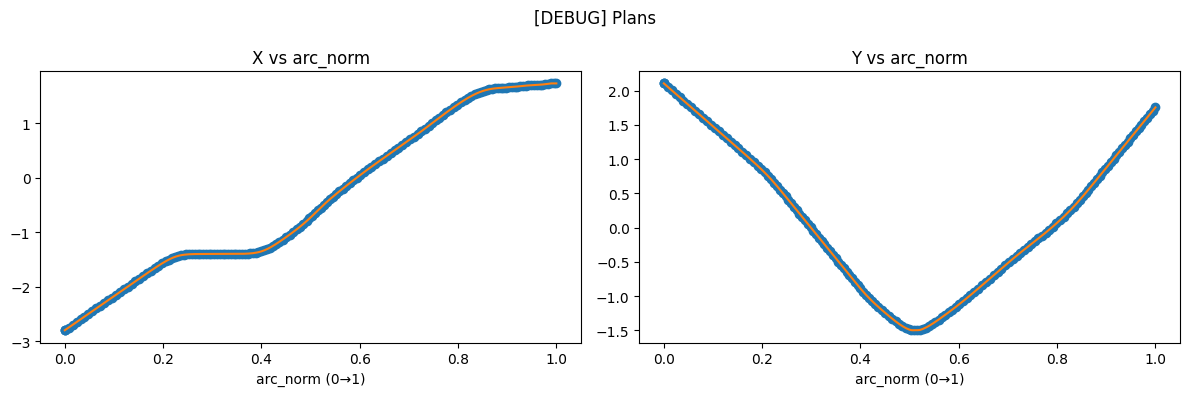

[winsorize_and_resample — plans]
  input rows    : 154
  limits        : (0.013, 0.013)
  pos_x range   : [-2.7519, 1.7269]
  pos_y range   : [-1.5093, 2.0549]
[arc_length_parametrize]
  n_points      : 154
  total length  : 8.8129 m
  arc[:5]  : [0.         0.         0.         0.07071068 0.14142136]
  arc[-5:] : [8.61177371 8.66222061 8.71293796 8.76293796 8.81293796]
  arc_norm[:5]  : [0.         0.         0.         0.00802351 0.01604702]
  arc_norm[-5:] : [0.97717398 0.98289817 0.98865305 0.99432652 1.        ]
  resampled to  : 500 points


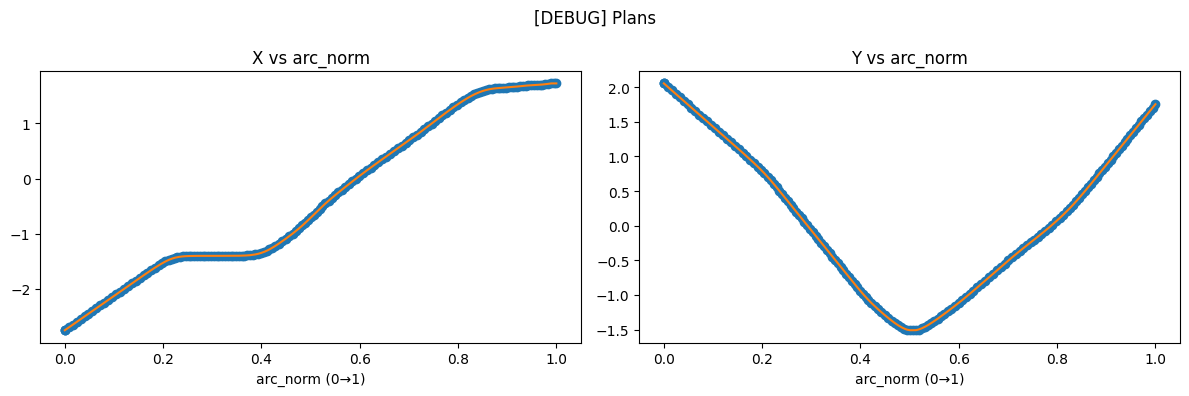

In [ ]:
def arc_length_parametrize(pos_x, pos_y):
    coords = np.column_stack([pos_x, pos_y])
    deltas = np.diff(coords, axis=0) # diff in each point 
    arc = np.concatenate([[0], np.cumsum(np.hypot(deltas[:, 0], deltas[:, 1]))])

    last_element = arc[-1]
    arc_norm = arc / last_element

    if DEBUG:
        print(f"[arc_length_parametrize]")
        print(f"  n_points      : {len(pos_x)}")
        print(f"  total length  : {last_element:.4f} m")
        print(f"  arc[:5]  : {arc[:5]}")
        print(f"  arc[-5:] : {arc[-5:]}")
        print(f"  arc_norm[:5]  : {arc_norm[:5]}")
        print(f"  arc_norm[-5:] : {arc_norm[-5:]}")

    return arc_norm

def plot_interpolation_check(u, pos_x, pos_y, t, fx, fy, title='Interpolation check'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(u, pos_x, 'o', t, fx(t), '-')
    ax1.set_title('X vs arc_norm')
    ax1.set_xlabel('arc_norm (0→1)')
    ax2.plot(u, pos_y, 'o', t, fy(t), '-')
    ax2.set_title('Y vs arc_norm')
    ax2.set_xlabel('arc_norm (0→1)')
    plt.suptitle(f'[DEBUG] {title}')
    plt.tight_layout()
    plt.show()

def winsorize_and_resample(df, x_col='pos_x', y_col='pos_y', limits=(0.013, 0.013), n_points=500):
    pos_x = np.array(winsorize(df[x_col], limits=limits))
    pos_y = np.array(winsorize(df[y_col], limits=limits))

    if DEBUG:
        print(f"[winsorize_and_resample — plans]")
        print(f"  input rows    : {len(df)}")
        print(f"  limits        : {limits}")
        print(f"  pos_x range   : [{pos_x.min():.4f}, {pos_x.max():.4f}]")
        print(f"  pos_y range   : [{pos_y.min():.4f}, {pos_y.max():.4f}]")

    u = arc_length_parametrize(pos_x, pos_y)

    t = np.linspace(0, 1, n_points)
    fx = interp1d(u, pos_x, kind='linear')
    fy = interp1d(u, pos_y, kind='linear')

    if DEBUG:
        print(f"  resampled to  : {n_points} points")
        plot_interpolation_check(u, pos_x, pos_y, t, fx, fy, title='Plans')

    return fx(t), fy(t)

# Plan paths (use x/y columns)
resampled_plans = [winsorize_and_resample(df, x_col='x', y_col='y') for df in last_plans]

plan_xs = np.array([p[0] for p in resampled_plans])
plan_ys = np.array([p[1] for p in resampled_plans])
median_plan_x = np.median(plan_xs, axis=0)
median_plan_y = np.median(plan_ys, axis=0)

In [394]:
fig = go.Figure()

for i, (px, py) in enumerate(resampled_plans):
    fig.add_trace(go.Scatter(
        x=px, y=py,
        mode='lines', name=f'Plan {i+1}',
        line=dict(color='tomato', width=1),
        opacity=0.3
    ))

fig.add_trace(go.Scatter(
    x=median_plan_x, y=median_plan_y,
    mode='lines', name='Median plan',
    line=dict(color='royalblue', dash='dash', width=3)
))

fig.update_layout(
    title='Plans + Median',
    xaxis_title='X (m)', yaxis_title='Y (m)',
    yaxis_scaleanchor='x', hovermode='closest'
)
fig.show()


##### 2.1.1 **Paths**

In [ ]:
def winsorize_and_resample(df, n_points=500):
    pos_x = np.array(winsorize(df['pos_x'], limits=(0.28, 0.00)))
    pos_y = np.array(winsorize(df['pos_y'], limits=(0.0, 0.32)))

    if DEBUG:
        print(f"[winsorize_and_resample — paths]")
        print(f"  input rows    : {len(df)}")
        print(f"  pos_x range   : [{pos_x.min():.4f}, {pos_x.max():.4f}]")
        print(f"  pos_y range   : [{pos_y.min():.4f}, {pos_y.max():.4f}]")

    arc_norm = arc_length_parametrize(pos_x, pos_y)

    t = np.linspace(0, 1, n_points)
    fx = interp1d(arc_norm, pos_x, kind='linear')
    fy = interp1d(arc_norm, pos_y, kind='linear')

    if DEBUG:
        print(f"  resampled to  : {n_points} points")

    return fx(t), fy(t)

resampled = [winsorize_and_resample(df) for df in actuals]

xs = np.array([p[0] for p in resampled])
ys = np.array([p[1] for p in resampled])

median_x = np.median(xs, axis=0)
median_y = np.median(ys, axis=0)

In [396]:
fig = go.Figure()

for i, (rx, ry) in enumerate(resampled):
    fig.add_trace(go.Scatter(
        x=rx, y=ry,
        mode='lines', name=f'Runs',
        line=dict(color='tomato', width=1),
        opacity=0.3,
        legendgroup='runs', showlegend=(i == 0)
    ))

fig.add_trace(go.Scatter(
    x=last_plan['x'], y=last_plan['y'],
    mode='lines', name='Planned path',
    line=dict(color='royalblue', dash='dash', width=2)
))
fig.add_trace(go.Scatter(
    x=median_x, y=median_y,
    mode='lines', name='Median path',
    line=dict(color='black', width=2.5)
))

fig.update_layout(
    title='Paths + Median',
    xaxis_title='X (m)', yaxis_title='Y (m)',
    yaxis_scaleanchor='x', hovermode='closest'
)
fig.show()

### 3. **Localization Quality**